# Loading content

## normalizing abundances

### volume-weighting DNA measurements

In [106]:
from math import pi
from pandas import read_csv, Series, DataFrame
import os
import cobra
# from modelseedpy import MSBuilder, MSATPCorrection, MSMedia, MSGapfill
# import modelseedpy
import json
from tqdm import tqdm
# from glob import glob
# import cobrakbase

dna_df = read_csv("../data/SaltPondsDNA.csv").set_index("Sample")
sample_dna = dna_df["DNA conc (µg/g soil)"].to_dict()
unique_prefixes = {"_".join(i.split("_")[:-1]) for i in dna_df.index}

volume_weighted_sample_dna = Series({
    prefix: (5*sample_dna[prefix+"_D1"] + 10*sample_dna[prefix+"_D2"]) / 15
    for prefix in unique_prefixes                                                                                                                                          
})

def fluxes_to_emissions(row):
    # TODO: LaTeX of the unit conversion
    # mmol/hr/g_bio -> umol/(m^2 * d)  via  / area (m^2) * (1000 umol / mmol) * (24 hours / day) * (g biomass / container)

    # defining the dimensions of the sampling system
    area_cm2 = pi * (5/2)**2 # cm^2
    area_m2 = area_cm2 * (1e-2)**2 # m^2
    volume_cm3 = 294.52 # cm^3

    # DNA per soil
    ugDNA_gSoil = volume_weighted_sample_dna.reindex(row.index).fillna(2) # 2 is the approximate average from the provided spreadsheet
    DNA_per_biomass = 0.1
    gSoil_cm3 = 0.7
    gBiomass_gSoil = gSoil_cm3 * volume_cm3 * ugDNA_gSoil / DNA_per_biomass / 1000 / 1000  # estimated from Chris' spreadsheet
    
    return row / area_m2 * 1e3 * 24 * (gBiomass_gSoil)


def merge_depths_by_DNA(abundances):
    # return DataFrame({prefix: mean(abundances[prefix+"_D1"] + abundances[prefix+"_D2"]) for prefix in unique_prefixes},
    #                     index=abundances.index)
    return DataFrame({prefix: (abundances[prefix+"_D1"]*sample_dna[prefix+"_D1"] + abundances[prefix+"_D2"]*sample_dna[prefix+"_D2"]) / (sample_dna[prefix+"_D1"] + sample_dna[prefix+"_D2"])
                    for prefix in unique_prefixes}, index=abundances.index)

### normalize the 

In [107]:
# load data
total_df = read_csv("../data/Cliff_Sample_Metadata_BGC_NMR.csv").set_index("Sample")
abundances = read_csv("../data/Cliff_310MAG_relabund.tsv", sep="\t")

# create DNA-normalized abundances for each depth
#TODO is this necessary?
normalized_abundances = abundances.copy()
for col, val in dna_df["DNA conc (µg/g soil)"].items():
    normalized_abundances[col] = normalized_abundances[col] / val

# find the 
unrestored_cols = [col for col in normalized_abundances.columns if ("R1_" in col or "R2_" in col)] # and "restored" not in col]
unrestored_avg_cols = list(set([col.split("_D")[0] for col in unrestored_cols]))
normalized_abundances.index.name = "MAG"
normalized_abundances.to_csv("normalized_MAG_abundances.csv")
display(normalized_abundances)

normalized_methane_df = total_df["CH4_umol_m2_d"] / dna_df["DNA conc (µg/g soil)"]
display(normalized_methane_df)
unique_prefixes = set(["_".join(col.split("_")[:-1]) for col in normalized_methane_df.index])
col_merged = {prefix: [prefix+"_D1", prefix+"_D2"] for prefix in unique_prefixes}
# averaged_normalized_abundances = DataFrame({prefix: normalized_abundances[cols].mean(axis=1) for prefix, cols in col_merged.items()}, index=normalized_abundances.index)
averaged_normalized_abundances = merge_depths_by_DNA(normalized_abundances)
unrestored_cols_simplified = [col for col in averaged_normalized_abundances.columns if ("R1_" in col or "R2_" in col)] # and "restored" not in col]
print(unrestored_cols, unrestored_avg_cols)
# averaged_normalized_abundances = normalized_abundances.groupby(prefixes, axis=1).mean()
averaged_normalized_abundances.to_csv("../data/averaged_normalized_MAG_abundances.csv")
display(averaged_normalized_abundances)
averaged_unrestored_normalized_abundances = averaged_normalized_abundances[unrestored_avg_cols]
averaged_unrestored_normalized_abundances.to_csv("../data/averaged_normalized_abundances_unrestored.csv")

averaged_normalized_methane = Series({prefix: normalized_methane_df[cols].mean() for prefix, cols in col_merged.items()}, index=col_merged.keys())
averaged_unrestored_normalized_methane = averaged_normalized_methane[unrestored_avg_cols]
methane_dic = averaged_unrestored_normalized_methane.to_dict()
json.dump(methane_dic, open("averaged_normalized_methane_unrestored.json", "w"), indent=3)
methane_dic

,SF2_A_D1,SF2_A_D2,SF2_B_D1,SF2_B_D2,SF2_C_D1,SF2_C_D2,R1_A_D1,R1_A_D2,R1_B_D1,R1_B_D2,...,R2A_B_D1,R2A_B_D2,R2A_C_D1,R2A_C_D2,R2_A_D1,R2_A_D2,R2_B_D1,R2_B_D2,R2_C_D1,R2_C_D2
MAG,,,,,,,,,,,,,,,,,,,,,
Salt_Pond_MetaGSF2_A_D1_MG_DASTool_bins_concoct_out.23,0.006616,0.006035,3.731061e-03,0.006515,0.007592,0.005036,1.644877e-07,2.926898e-07,6.317685e-07,3.836137e-07,...,7.961735e-05,0.000773,0.000033,0.000057,3.459632e-07,0.000001,0.000021,6.398778e-07,1.452263e-06,0.000014
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.11,0.000352,0.000896,7.186752e-04,0.001256,0.002582,0.002143,1.930943e-07,1.573208e-07,1.340115e-07,4.583437e-07,...,2.618992e-06,0.000037,0.000004,0.000002,8.649080e-07,0.000001,0.000005,5.576078e-07,8.220354e-08,0.000010
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.13,0.000446,0.005475,1.458375e-03,0.003433,0.012013,0.013398,2.252767e-07,2.012243e-07,5.130726e-07,2.192078e-07,...,4.467692e-06,0.000415,0.000029,0.000542,1.049684e-06,0.000002,0.000026,6.947245e-07,9.919227e-07,0.000011
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.28,0.004389,0.008007,1.392826e-02,0.025495,0.021325,0.023352,2.109734e-07,3.219588e-07,4.862703e-07,3.836137e-07,...,3.981895e-05,0.002120,0.000034,0.000205,1.191214e-06,0.000003,0.000024,1.000952e-06,1.227573e-06,0.000015
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.33,0.000069,0.002987,4.803627e-05,0.000114,0.000149,0.003686,4.398259e-06,3.395202e-06,5.701232e-06,7.373355e-06,...,5.118845e-05,0.001487,0.000070,0.000513,3.742693e-06,0.000004,0.000190,1.611578e-05,1.103172e-05,0.000106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_concoct_out.44,0.000001,0.000002,9.636456e-07,0.000002,0.000002,0.000003,1.394570e-07,2.597622e-07,3.867189e-07,5.579836e-07,...,8.935384e-07,0.000010,0.000002,0.000003,8.090821e-05,0.000029,0.000103,1.487350e-04,1.742715e-06,0.005099
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.002,0.000002,0.000003,1.533073e-06,0.000003,0.000005,0.000005,3.861886e-07,6.695280e-07,2.059948e-06,2.979234e-06,...,2.536827e-06,0.000019,0.000003,0.000004,3.975864e-04,0.000110,0.000462,5.955206e-04,4.981535e-06,0.017430
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.005,0.000005,0.000003,2.890937e-06,0.000005,0.000006,0.000004,4.866691e-06,6.987969e-06,2.025488e-05,2.169161e-05,...,7.600211e-07,0.000011,0.000002,0.000002,6.362185e-05,0.000072,0.000509,3.977298e-05,4.194573e-05,0.000810


Sample
R1_A_D1       152.928650
R1_A_D2       155.159933
R1_B_D1       311.067580
R1_B_D2       390.397025
R1_C_D1       293.811901
R1_C_D2       232.230114
R2A_A_D1       -5.576805
R2A_A_D2      -62.329001
R2A_B_D1       -0.781991
R2A_B_D2       -6.432749
R2A_C_D1       -4.654720
R2A_C_D2       -7.314560
R2_A_D1       332.237984
R2_A_D2       846.415816
R2_B_D1     10044.312500
R2_B_D2       572.869534
R2_C_D1       466.860306
R2_C_D2      9961.768374
SF2_A_D1        3.775568
SF2_A_D2        3.792808
SF2_B_D1       33.499461
SF2_B_D2       68.174342
SF2_C_D1       18.229167
SF2_C_D2       23.748492
dtype: float64

['R1_A_D1', 'R1_A_D2', 'R1_B_D1', 'R1_B_D2', 'R1_C_D1', 'R1_C_D2', 'R2_A_D1', 'R2_A_D2', 'R2_B_D1', 'R2_B_D2', 'R2_C_D1', 'R2_C_D2'] ['R1_B', 'R1_C', 'R2_B', 'R2_C', 'R2_A', 'R1_A']


,R1_B,R1_C,R2_B,R2A_C,R2_C,SF2_B,SF2_A,SF2_C,R2A_B,R2A_A,R2_A,R1_A
MAG,,,,,,,,,,,,
Salt_Pond_MetaGSF2_A_D1_MG_DASTool_bins_concoct_out.23,5.217232e-07,1.286943e-06,1.758620e-06,0.000043,2.025077e-06,0.004648,0.006326,0.006482,0.000155,0.000304,5.329121e-07,2.281245e-07
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.11,2.778380e-07,1.187038e-06,8.034564e-07,0.000003,5.352400e-07,0.000896,0.000623,0.002391,0.000006,0.000032,9.825511e-07,1.753371e-07
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.13,3.827570e-07,6.725687e-07,2.065217e-06,0.000228,1.435731e-06,0.002109,0.002955,0.012614,0.000049,0.000005,1.249110e-06,2.133376e-07
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.28,4.407468e-07,1.234089e-06,2.255867e-06,0.000101,1.826195e-06,0.017739,0.006194,0.022205,0.000265,0.000047,1.564934e-06,2.660642e-07
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.33,6.442742e-06,1.483049e-05,2.547706e-05,0.000242,1.527826e-05,0.000070,0.001525,0.001685,0.000207,0.000018,3.735220e-06,3.900363e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_concoct_out.44,4.626670e-07,3.654357e-06,1.462709e-04,0.000002,2.299363e-04,0.000001,0.000002,0.000003,0.000002,0.000003,6.625106e-05,1.991740e-07
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.002,2.467609e-06,1.434370e-05,5.882931e-04,0.000003,7.850508e-04,0.000002,0.000003,0.000005,0.000004,0.000008,3.166460e-04,5.268323e-07
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.005,2.089201e-05,2.118231e-05,6.509313e-05,0.000002,7.632178e-05,0.000004,0.000004,0.000005,0.000002,0.000001,6.603605e-05,5.919649e-06


{'R1_B': 350.7323023585634,
 'R1_C': 263.0210073267493,
 'R2_B': 5308.591017144301,
 'R2_C': 5214.314339711316,
 'R2_A': 589.3269001387226,
 'R1_A': 154.04429155649183}

In [108]:
media = {'EX_cpd00067_e0': 1000.0,
 'EX_cpd00058_e0': 1000.0,
 'EX_cpd00013_e0': 1000.0,
 'EX_cpd00244_e0': 1000.0,
 'EX_cpd00205_e0': 1000.0,
 'EX_cpd00034_e0': 1000.0,
 'EX_cpd11574_e0': 1000.0,
 'EX_cpd00971_e0': 1000.0,
 'EX_cpd00048_e0': 1000.0,
 'EX_cpd00030_e0': 1000.0,
 'EX_cpd00305_e0': 100.0,
 'EX_cpd00001_e0': 1000.0,
 'EX_cpd10516_e0': 1000.0,
 'EX_cpd00007_e0': 1000.0,
 'EX_cpd00159_e0': 100.0,
 'EX_cpd25960_e0': 1000.0,
 "EX_cpd00009_e0": 100,
 'EX_cpd00063_e0': 1000.0,
 'EX_cpd00149_e0': 1000.0,
 'EX_cpd00254_e0': 1000.0,
 'EX_cpd00099_e0': 1000.0}

In [109]:
mepe = {  #mepn
    'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs',
 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs',
 'Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs',
 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs',
 'Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.143.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.10.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.47.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'}
mepe_striped = [x.replace(".contigs","") for x in mepe]


betaine = {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs',
 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs',
 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs',
 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs',
 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs',
 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs',
 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs',
 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs',
 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs',
 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs',
 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs',
 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs'}
betaine_striped = [x.replace(".contigs","") for x in betaine]

In [6]:
models = {}
for i in tqdm(mepe):
    # filename_model = f'./genome_scale/{i}.json'
    filename_model = f'../models/MePn_consumers/{i}.json'
    if os.path.exists(filename_model):
        models[i] = cobra.io.load_json_model(filename_model)
    else:
        print(f'skip {i}')

  0%|          | 0/27 [00:00<?, ?it/s]

 11%|█         | 3/27 [00:01<00:11,  2.13it/s]

skip Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14.contigs


 63%|██████▎   | 17/27 [00:06<00:04,  2.32it/s]

skip Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs


 81%|████████▏ | 22/27 [00:08<00:02,  2.16it/s]

skip Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16.contigs


100%|██████████| 27/27 [00:10<00:00,  2.61it/s]


In [7]:
from modelseedpy.biochem import from_local
# msdb = from_local("../../../shared/code/ModelSEEDDatabase")
msdb = from_local("../../../ModelSEEDDatabase")

for cpd in media:
    print(msdb.compounds.get_by_id(cpd.split("_")[1]).name, "\t", cpd.id)

AttributeError: 'str' object has no attribute 'id'

# determine methane emission from methylphosphate as the sole phosphate source on lactate

In [ ]:
methane_emissions = {}
for ID, model in models.items():
    model.medium = media
    sol = model.optimize()
    if sol.objective_value == 0:
        print(f"{ID} failed") #, end="\n\n")
        continue
    methane_emissions[ID] = sol.fluxes['EX_cpd01024_e0']
    # print(f"{sol.fluxes['EX_cpd01024_e0']} methane flux from {ID}")

methane_emissions = dict(sorted(methane_emissions.items(), key=lambda item: item[1], reverse=True))
print()
print("methane emissions in optimum growth")
display(methane_emissions)

Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs failed
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs failed
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs failed
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs failed

methane emissions in optimum growth


{'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs': np.float64(2.5864849729522366),
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs': np.float64(2.2076584819206517),
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs': np.float64(2.1903232072259486),
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs': np.float64(0.0),
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs': np.float64(0.0),
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs': np.float64(0.0),
 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs': np.float64(0.0),
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.47.contigs': np.float64(0.0),
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs': np.float64(0.0),
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs': np.float64(0.0),
 'Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs': np.float64(0.0),
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_m

## compare with the abundances of each respective species

In [ ]:
# import json
# abundances = json.load()
from pandas import read_csv

display(abundances)
# row/organism sum
unrestored = abundances[abundances.index.to_series().str.contains(r'R1|R2')]
member_totals = unrestored.sum(axis=1).sort_values(ascending=False)
most_abundant_members = member_totals[:8]
display(most_abundant_members)
# column/sample sum
unrestored_cols = [col for col in abundances.columns if ("R1_" in col or "R2_" in col)]
display(abundances[unrestored_cols].sum(axis=1).sort_values(ascending=False)[:8])
#NOTE:  the subtle differences between these 2 abundance sums mean that these organisms are present in restored samples

sample_totals = abundances.sum(axis=0)
display(sample_totals)

,SF2_A_D1,SF2_A_D2,SF2_B_D1,SF2_B_D2,SF2_C_D1,SF2_C_D2,R1_A_D1,R1_A_D2,R1_B_D1,R1_B_D2,...,R2A_B_D1,R2A_B_D2,R2A_C_D1,R2A_C_D2,R2_A_D1,R2_A_D2,R2_B_D1,R2_B_D2,R2_C_D1,R2_C_D2
Salt_Pond_MetaGSF2_A_D1_MG_DASTool_bins_concoct_out.23,0.007762,0.007049,0.004617,0.003961,0.004373,0.002226,7.930502e-07,1.390862e-06,2.735979e-06,1.323723e-06,...,0.000179,0.000212,0.000051,0.000056,0.000001,0.000002,3.419824e-06,0.000002,4.941565e-06,0.000002
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.11,0.000413,0.001046,0.000889,0.000764,0.001487,0.000948,9.309720e-07,7.475883e-07,5.803591e-07,1.581591e-06,...,0.000006,0.000010,0.000006,0.000002,0.000003,0.000002,8.182401e-07,0.000002,2.797112e-07,0.000002
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.13,0.000524,0.006394,0.001804,0.002087,0.006919,0.005924,1.086134e-06,9.562176e-07,2.221946e-06,7.564132e-07,...,0.000010,0.000114,0.000044,0.000526,0.000004,0.000003,4.175123e-06,0.000002,3.375182e-06,0.000002
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.28,0.005150,0.009352,0.017234,0.015501,0.012283,0.010325,1.017173e-06,1.529948e-06,2.105874e-06,1.323723e-06,...,0.000090,0.000580,0.000052,0.000199,0.000005,0.000004,3.881395e-06,0.000003,4.177021e-06,0.000002
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.33,0.000081,0.003488,0.000059,0.000069,0.000086,0.001630,2.120547e-05,1.613400e-05,2.469013e-05,2.544299e-05,...,0.000115,0.000407,0.000107,0.000498,0.000015,0.000006,3.033782e-05,0.000045,3.753725e-05,0.000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_concoct_out.44,0.000002,0.000003,0.000001,0.000001,0.000001,0.000001,6.723687e-07,1.234390e-06,1.674751e-06,1.925415e-06,...,0.000002,0.000003,0.000003,0.000002,0.000323,0.000045,1.649068e-05,0.000417,5.929878e-06,0.000813
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.002,0.000002,0.000004,0.000002,0.000002,0.000003,0.000002,1.861944e-06,3.181597e-06,8.920949e-06,1.028034e-05,...,0.000006,0.000005,0.000004,0.000004,0.001588,0.000173,7.385141e-05,0.001671,1.695050e-05,0.002780
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.005,0.000006,0.000003,0.000004,0.000003,0.000003,0.000002,2.346394e-05,3.320683e-05,8.771713e-05,7.485053e-05,...,0.000002,0.000003,0.000003,0.000002,0.000254,0.000113,8.144636e-05,0.000112,1.427273e-04,0.000129
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.017,0.000003,0.000002,0.000002,0.000002,0.000002,0.000002,3.748024e-05,4.779350e-05,3.856901e-05,5.152205e-05,...,0.000003,0.000002,0.000002,0.000001,0.000145,0.000045,5.744465e-05,0.000159,5.320108e-05,0.000174


Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_metabat.12    0.320442
Salt_Pond_MetaG_R2_B_D1_MG_DASTool_bins_metabat.13    0.225916
Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.28    0.199881
Salt_Pond_MetaG_R2_B_D1_MG_DASTool_bins_metabat.10    0.184577
Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.19    0.167538
Salt_Pond_MetaG_R1_A_H2O_MG_DASTool_bins_metabat.8    0.139007
Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.29    0.119100
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17    0.115763
dtype: float64

unbinned_reads                                        6.293739
Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_metabat.12    0.319672
Salt_Pond_MetaG_R2_B_D1_MG_DASTool_bins_metabat.13    0.224310
Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.28    0.199736
Salt_Pond_MetaG_R2_B_D1_MG_DASTool_bins_metabat.10    0.184458
Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.19    0.167473
Salt_Pond_MetaG_R1_A_H2O_MG_DASTool_bins_metabat.8    0.138756
Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.29    0.118720
dtype: float64

SF2_A_D1    1.0
SF2_A_D2    1.0
SF2_B_D1    1.0
SF2_B_D2    1.0
SF2_C_D1    1.0
SF2_C_D2    1.0
R1_A_D1     1.0
R1_A_D2     1.0
R1_B_D1     1.0
R1_B_D2     1.0
R1_C_D1     1.0
R1_C_D2     1.0
R2A_A_D1    1.0
R2A_A_D2    1.0
R2A_B_D1    1.0
R2A_B_D2    1.0
R2A_C_D1    1.0
R2A_C_D2    1.0
R2_A_D1     1.0
R2_A_D2     1.0
R2_B_D1     1.0
R2_B_D2     1.0
R2_C_D1     1.0
R2_C_D2     1.0
dtype: float64

# notes
- the Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17 organism both generates the most methane emission of all organisms and is the only one of the most abundant members that was defined with a model in the MePn set of organisms
- 

In [ ]:
from pandas import read_csv

# convert the experimental methane into the units of modeling methane flux
def convert_methane(methane):
    # umol/(m^2 * d) -> mmol/hr  via  * area (m^2) * (1 mmol/1000 umol) * (1 day / 24 hours)
    from math import pi
    # sample_volume = 294.52 # cm^3
    sample_area = pi * (5/2)**2 # cm^2
    # sample_volume = sample_volume * (1e-2)**3 # m^3
    sample_area = sample_area * (1e-2)**2 # m^2
    gBiomass_gSoil = 5.9 * 1000
    return methane * sample_area / (1e3 * 24)

# normalize the DNA/g by the methane flux
methane = convert_methane(total_df["CH4_umol_m2_d"])
dna_df.drop(columns=[col for col in dna_df.columns if "named" in col.lower()], inplace=True)
for sample in dna_df.index:
    dna_df.loc[sample, "methane"] = methane[sample]  # mmol/hr
    dna_df.loc[sample, "CH4 (mmol/hr) / normalized_DNA"] = dna_df.loc[sample, "methane"] / dna_df.loc[sample, "DNA conc (µg/g soil)"]

# normalize to 1
# total_normalized_dna = dna_df.loc[:, "DNA/g/methane"].sum()
# dna_df["normalized DNA/g/methane"] = dna_df["DNA/g/methane"] / total_normalized_dna

display(dna_df)
dna_df.to_csv("../data/SaltPondsDNA_methane_weighted.csv")

NameError: name 'total_df' is not defined

# correlate the normalized abundances of members with the normalized methane flux

In [ ]:
normalized_methane = read_csv("../data/SaltPondsDNA_methane_weighted.csv").set_index("Sample")["CH4 (mmol/hr) / normalized_DNA"]
display(normalized_methane)

correlations = {}
for index, row in normalized_abundances.iterrows():
    corr = row.corr(normalized_methane, method="spearman")
    correlations[index] = corr

correlations = dict(sorted(correlations.items(), key=lambda item: item[1], reverse=True))
# print("total correlation", sum(correlations.values()))
merged_corr = 0
for org, val in correlations.items():
    if org in mepe_striped:  merged_corr += val
# print("summed mepe correlations", merged_corr)
print("max all correlations", max(correlations.values()))
unrestored_correlations = {k:v for k,v in correlations.items() if ("R1_" in k or "R2_" in k) and not "restored" in k}
print(unrestored_correlations['Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17'])
display(unrestored_correlations)

import numpy as np
print(np.mean(list(unrestored_correlations.values())), np.mean(list(unrestored_correlations.values()))**2, np.std(list(unrestored_correlations.values())))

Sample
R1_A_D1     1.251145e-05
R1_A_D2     1.269399e-05
R1_B_D1     2.544916e-05
R1_B_D2     3.193928e-05
R1_C_D1     2.403743e-05
R1_C_D2     1.899928e-05
R2_A_D1     2.718116e-05
R2_A_D2     6.924723e-05
R2_B_D1     8.217484e-04
R2_B_D2     4.686778e-05
R2_C_D1     3.819492e-05
R2_C_D2     8.149953e-04
R2A_A_D1   -4.562513e-07
R2A_A_D2   -5.099279e-06
R2A_B_D1   -6.397645e-08
R2A_B_D2   -5.262780e-07
R2A_C_D1   -3.808134e-07
R2A_C_D2   -5.984211e-07
SF2_A_D1    3.088879e-07
SF2_A_D2    3.102984e-07
SF2_B_D1    2.740668e-06
SF2_B_D2    5.577500e-06
SF2_C_D1    1.491370e-06
SF2_C_D2    1.942919e-06
Name: CH4 (mmol/hr) / normalized_DNA, dtype: float64

NameError: name 'normalized_abundances' is not defined

## look at the total abundances of MePn consumers and betaine reducers

In [ ]:
merged_normalized_abundances = normalized_abundances.copy()
merged_normalized_abundances.loc["mepe"] = normalized_abundances.loc[mepe_striped].sum()
merged_normalized_abundances.loc["betaine_reducers"] = normalized_abundances.loc[betaine_striped].sum()
merged_normalized_abundances = merged_normalized_abundances.drop(mepe_striped)
merged_normalized_abundances

,SF2_A_D1,SF2_A_D2,SF2_B_D1,SF2_B_D2,SF2_C_D1,SF2_C_D2,R1_A_D1,R1_A_D2,R1_B_D1,R1_B_D2,...,R2A_B_D1,R2A_B_D2,R2A_C_D1,R2A_C_D2,R2_A_D1,R2_A_D2,R2_B_D1,R2_B_D2,R2_C_D1,R2_C_D2
Salt_Pond_MetaGSF2_A_D1_MG_DASTool_bins_concoct_out.23,0.006616,0.006035,0.003731,0.006515,0.007592,0.005036,1.644877e-07,2.926898e-07,6.317685e-07,3.836137e-07,...,7.961735e-05,0.000773,0.000033,0.000057,3.459632e-07,0.000001,0.000021,6.398778e-07,1.452263e-06,0.000014
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.11,0.000352,0.000896,0.000719,0.001256,0.002582,0.002143,1.930943e-07,1.573208e-07,1.340115e-07,4.583437e-07,...,2.618992e-06,0.000037,0.000004,0.000002,8.649080e-07,0.000001,0.000005,5.576078e-07,8.220354e-08,0.000010
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.13,0.000446,0.005475,0.001458,0.003433,0.012013,0.013398,2.252767e-07,2.012243e-07,5.130726e-07,2.192078e-07,...,4.467692e-06,0.000415,0.000029,0.000542,1.049684e-06,0.000002,0.000026,6.947245e-07,9.919227e-07,0.000011
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.28,0.004389,0.008007,0.013928,0.025495,0.021325,0.023352,2.109734e-07,3.219588e-07,4.862703e-07,3.836137e-07,...,3.981895e-05,0.002120,0.000034,0.000205,1.191214e-06,0.000003,0.000024,1.000952e-06,1.227573e-06,0.000015
Salt_Pond_MetaGSF2_A_D2_MG_DASTool_bins_concoct_out.33,0.000069,0.002987,0.000048,0.000114,0.000149,0.003686,4.398259e-06,3.395202e-06,5.701232e-06,7.373355e-06,...,5.118845e-05,0.001487,0.000070,0.000513,3.742693e-06,0.000004,0.000190,1.611578e-05,1.103172e-05,0.000106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.005,0.000005,0.000003,0.000003,0.000005,0.000006,0.000004,4.866691e-06,6.987969e-06,2.025488e-05,2.169161e-05,...,7.600211e-07,0.000011,0.000002,0.000002,6.362185e-05,0.000072,0.000509,3.977298e-05,4.194573e-05,0.000810
Salt_Pond_MetaG_R2_restored_H2O_MG_DASTool_bins_maxbin.017,0.000002,0.000002,0.000002,0.000003,0.000004,0.000004,7.773833e-06,1.005755e-05,8.906021e-06,1.493104e-05,...,1.119491e-06,0.000008,0.000002,0.000002,3.631827e-05,0.000029,0.000359,5.656977e-05,1.563511e-05,0.001089
unbinned_reads,0.804522,0.759152,0.732928,1.463329,1.602282,1.708192,9.309582e-02,9.058212e-02,1.156331e-01,1.228118e-01,...,4.155628e-01,3.359769,0.557968,0.821472,1.608085e-01,0.343942,3.859278,1.933192e-01,1.658099e-01,3.595310
mepe,0.000595,0.000745,0.001242,0.003200,0.001659,0.003441,1.387740e-02,1.490227e-02,2.393991e-02,2.761568e-02,...,1.615404e-03,0.004680,0.001490,0.001183,1.827708e-02,0.024067,0.434797,4.643770e-02,2.330005e-02,0.564502


# MePn reducers

# TODO correlate with all the experimental metabolites, including MePn

In [ ]:
merged_correlations = {}
for index, row in merged_normalized_abundances.iterrows():
    corr = row.corr(normalized_methane, method="spearman")
    merged_correlations[index] = corr
    # print(f"{index} correlates {corr} with methane")

merged_correlations = dict(sorted(merged_correlations.items(), key=lambda item: item[1], reverse=True))
merged_correlations
# print("max all correlations", max(merged_correlations.values()))
# unrestored_merged_correlations = {k:v for k,v in merged_correlations.items() if ("R1_" in k or "R2_" in k) and not "restored" in k}
# unrestored_merged_correlations

{'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.13': np.float64(0.9922588688990923),
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.98': np.float64(0.9897259768241059),
 'Salt_Pond_MetaG_R2_B_D1_MG_DASTool_bins_metabat.13': np.float64(0.9876012116481486),
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.16': np.float64(0.9872359225769332),
 'mepe': np.float64(0.986741540640257),
 'Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.5': np.float64(0.9854061134057847),
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.30': np.float64(0.9837327339337952),
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52': np.float64(0.9830769058301974),
 'Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.11': np.float64(0.9822720369608353),
 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.30': np.float64(0.9822702702526581),
 'Salt_Pond_MetaG_R2_B_D1_MG_DASTool_bins_concoct_out.40': np.float64(0.9819724781554824),
 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.36': np.float64(0.9

# Simulation

In [ ]:
display(cobra.Configuration())
dontGrow = []
for ID, model in models.items():
    ogMedia = model.medium
    model.medium = media
    sol = model.optimize()
    if sol.status == "infeasible":
        print(ID, "is infeasible")
    elif sol.objective_value == 0:
        print(ID, "doesn't grow")
        dontGrow.append(ID)
    else: print(sol)
    model.medium = ogMedia

<Solution 5.118 at 0x16b5ac250>
<Solution 4.006 at 0x30ac52690>
<Solution 5.084 at 0x30ac532d0>
<Solution 4.976 at 0x30ac500d0>
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs doesn't grow
<Solution 4.866 at 0x30ac516d0>
<Solution 5.084 at 0x30ac50990>
<Solution 0.002 at 0x30ac52690>
<Solution 5.150 at 0x30ac50350>
<Solution 0.002 at 0x30ac50390>
<Solution 0.002 at 0x30ac50190>
<Solution 5.106 at 0x30ac50e50>
<Solution 5.114 at 0x30ac50910>
<Solution 5.023 at 0x30ac50050>
<Solution 4.695 at 0x30ac50d90>
<Solution 4.990 at 0x30ac53290>
<Solution 5.111 at 0x30ac512d0>
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs doesn't grow
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs doesn't grow
<Solution 5.136 at 0x30ac50150>
<Solution 5.024 at 0x30ac50310>
Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs doesn't grow
<Solution 5.093 at 0x30ac50050>
<Solution 5.148 at 0x30ac511d0>


## simulate the MePn-consuming organisms

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from optlang.symbolics import Zero
import numpy as np

sols = {}
# methane_production, lactate_consumption, = {}, {}
# media["EX_cpd00009_e0"] = 10
fits, fluxes = {}, {}

with open("sols_log.txt", 'w') as f:
    for multiple in [0.07, .33]: # + list(np.logspace(-1, 1, 10)):
        fluxes[multiple] = {"methane": {}, "lactate": {}, "phosphate": {}, "MePn": {}}
        for orgID, row in averaged_unrestored_normalized_abundances.iterrows():
            # print(orgID)
            ID = orgID+".contigs"
            if ID not in models or ID in dontGrow:  continue
            model = models[ID].copy()

            # phosphate ratio constraint
            constraint = model.problem.Constraint(Zero, lb=0, ub=None, name="Phosphate_ratio")
            model.add_cons_vars(constraint)
            model.solver.update()
            # MePn >= multiple * Pi
            constraint.set_linear_coefficients(coefficients = {
                model.reactions.EX_cpd00009_e0.forward_variable: multiple,
                model.reactions.EX_cpd00009_e0.reverse_variable: -multiple,
                model.reactions.EX_cpd25960_e0.forward_variable: -1,
                model.reactions.EX_cpd25960_e0.reverse_variable: 1})
                # model.reactions.EX_cpd00009_e0.forward_variable: multiple,
                # model.reactions.EX_cpd25960_e0.forward_variable: -1})
            # display(constraint.ub, constraint.expression, constraint.lb)
            model.solver.update()
            
            model.medium = media
            bio = model.reactions.get_by_id("bio1")
            model.solver.configuration.timeout = 15
            sols[ID] = {}
            for k, dic in fluxes[multiple].items():
                fluxes[multiple][k][ID] = {}
            f.write(f"\n\n{orgID}")
            for sample, abundance in row.items():
                # fix the biomass
                bio.bounds = (abundance, abundance)
                # define lactate as a the objective
                EX = model.reactions.get_by_id("EX_cpd00159_e0")
                EX.bounds = (-1000, 0)
                model.objective = EX
                f.write(f"\noptimizing {sample} at {abundance}")
                sols[ID][sample] = model.optimize()
                if sols[ID][sample].status == "infeasible":
                    f.write(f"Feasibility Error: {ID} {sample}")
                
                fluxes[multiple]["methane"][ID][sample] = sols[ID][sample].fluxes.EX_cpd01024_e0
                fluxes[multiple]["lactate"][ID][sample] = sols[ID][sample].fluxes.EX_cpd00159_e0
                fluxes[multiple]["phosphate"][ID][sample] = sols[ID][sample].fluxes.EX_cpd00009_e0
                # fluxes[multiple]["phosphate"][ID][sample] = model.reactions.EX_cpd00009_e0.reverse_variable.primal
                fluxes[multiple]["MePn"][ID][sample] = sols[ID][sample].fluxes.EX_cpd25960_e0
                # fluxes[multiple]["MePn"][ID][sample] = model.reactions.EX_cpd25960_e0.reverse_variable.primal
                
                bio.bounds = (0, 0)
                bio_flux = sols[ID][sample].fluxes.bio1
                if bio_flux != abundance:
                    f.write(f"\nAbundance Error: {bio_flux} != {abundance}")
                f.write(f"\noptimized at {sols[ID][sample].fluxes.EX_cpd00159_e0}")
    
        # determine the linear regression of fitting the experimental data with the simulation fluxes
        mdl = LinearRegression()
        xs = np.array(list(methane_dic.values())).reshape(-1, 1)
        methane_df = DataFrame(fluxes[multiple]["methane"])
        ys = np.array(fluxes_to_emissions(methane_df.T.sum()).to_list())
        mdl.fit(xs, ys)
        y_pred = mdl.predict(xs)
        fits[multiple] = {"eq": f"y = {mdl.coef_[0]:.2f}x + {mdl.intercept_:.2f}",
                          "R2": f"$R^2$ = {r2_score(ys, y_pred):.8f}"}

        mepn_df = DataFrame(fluxes[multiple]["MePn"])
        phosphate_df = DataFrame(fluxes[multiple]["phosphate"])
        # display(mepn_df)
        print("\nMinimum MePn/Phosphate ratio", multiple)
        print("total MePn consumed:", mepn_df.sum(axis=1).to_dict())
        print("total inorganic Phosphate consumed:", phosphate_df.sum(axis=1).to_dict())
        print(fits[multiple])
        # print(sum(list(.values()))
        # break
        # print(fluxes[multiple]["phosphate"]['Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs'])
        # print(fluxes[multiple]["MePn"]['Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs'])

json.dump(fits, open("fits.json", 'w'), indent=3)
json.dump(fluxes, open("saltern_fluxes.json", 'w'), indent=3)

/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f


Minimum MePn/Phosphate ratio 0.07
total MePn consumed: {'R2_C': -0.028365322674484703, 'R1_A': -0.0017717546724596899, 'R2_B': -0.027858955793534822, 'R2_A': -0.001641265739627526, 'R1_C': -0.005920965529428517, 'R1_B': -0.0028507609560914395}
total inorganic Phosphate consumed: {'R2_C': -0.14867171963939776, 'R1_A': -0.007103016454197414, 'R2_B': -0.10928480236801683, 'R2_A': -0.007311309058859013, 'R1_C': -0.022707394458154877, 'R1_B': -0.012291319596803485}
{'eq': 'y = 0.51x + 138.48', 'R2': '$R^2$ = 0.97828062'}


/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f


Minimum MePn/Phosphate ratio 0.33
total MePn consumed: {'R2_C': -0.056440860480034764, 'R1_A': -0.003085649417768163, 'R2_B': -0.048044952158359015, 'R2_A': -0.003010561802076154, 'R1_C': -0.010098177352233666, 'R1_B': -0.005143213806276558}
total inorganic Phosphate consumed: {'R2_C': -0.12059618183613853, 'R1_A': -0.005789121709098119, 'R2_B': -0.08909880600318905, 'R2_A': -0.005942012996409809, 'R1_C': -0.018530182635350365, 'R1_B': -0.009998866746618838}
{'eq': 'y = 0.95x + 223.77', 'R2': '$R^2$ = 0.96812476'}


/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


### compute the methane emission from substrate addition of MePn

In [ ]:
additional_methane_generated = 10 # umol
hours_equilibrated = 14 * 24 # hours
volume_added = 10 # mL
concentration_added = 100 # umol/L
substrate_added = concentration_added * (volume_added/1000)  # umol
print("substrate added", substrate_added)
substrate_flux = substrate_added #  / hours_equilibrated  # not divided by time because all of the substrate was added at once
additional_methane_flux = additional_methane_generated / hours_equilibrated  # umol/hr
print(additional_methane_flux, "umol/hr methane flux from addition")

0.02976190476190476 umol/hr methane flux from addition


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from optlang.symbolics import Zero
import numpy as np

# methane_production, lactate_consumption, = {}, {}
# media["EX_cpd00009_e0"] = 10
 # mmol and divided by 3 to account for the lack of a community model to share it among all members
 ## yet there are generally 1-3 MePn consumers per sample so dividing by 3 is a reasonable approximation
media["EX_cpd25960_e0"] = substrate_flux / 1000 # / 3   # mmol
display(media)
print("members", len(averaged_unrestored_normalized_abundances.index))
fits_addition, fluxes_addition = {}, {}
MePn_consumers = {}

fluxes_addition = {"methane": {}, "lactate": {}, "phosphate": {}, "MePn": {}}
total_methane_emissions = np.array([0.0]*len(averaged_unrestored_normalized_abundances.columns))
total_MePn_consumption = np.array([0.0]*len(averaged_unrestored_normalized_abundances.columns))
for orgID, row in averaged_unrestored_normalized_abundances.iterrows():
    # print(orgID)
    ID = orgID+".contigs"
    if ID not in models or ID in dontGrow:  continue
    model = models[ID].copy()


    model.medium = media
    bio = model.reactions.get_by_id("bio1")
    model.solver.configuration.timeout = 15
    for k, dic in fluxes_addition.items():
        fluxes_addition[k][ID] = {}
    for sample, abundance in row.items():
        # constrain biomass and lactate consumption
        bio.bounds = (abundance, abundance)
        EX = model.reactions.get_by_id("EX_cpd00159_e0")
        # EX.bounds = (-1000, 0)
        model.objective = EX
        # model.objective_direction = "max"
        # print(model.reactions.get_by_id("EX_cpd25960_e0").bounds)
        # model.reactions.get_by_id("EX_cpd25960_e0").lower_bound = -media["EX_cpd25960_e0"]
        sol = model.optimize()
        if sol.status == "infeasible":
            print(f"Feasibility Error: {ID} in {sample}")
            continue

        if abs(sol.fluxes.EX_cpd25960_e0) > 1e-9:
            MePn_consumers[sample] = MePn_consumers.get(sample, set())
            MePn_consumers[sample].add(ID)
        if abs(model.reactions.get_by_id("EX_cpd25960_e0").lower_bound) < abs(sol.fluxes.EX_cpd25960_e0):
            display(model.medium)
            raise ValueError(f"MePn flux {sol.fluxes.EX_cpd25960_e0} is greater than the lower bound \
                {model.reactions.get_by_id('EX_cpd25960_e0').lower_bound} for {ID} {sample}")

        fluxes_addition["methane"][ID][sample] = sol.fluxes.EX_cpd01024_e0
        fluxes_addition["lactate"][ID][sample] = sol.fluxes.EX_cpd00159_e0
        fluxes_addition["phosphate"][ID][sample] = sol.fluxes.EX_cpd00009_e0
        fluxes_addition["MePn"][ID][sample] = sol.fluxes.EX_cpd25960_e0
        
        bio.bounds = (0, 0)
        bio_flux = sol.fluxes.bio1
        if bio_flux != abundance:
            print(f"Abundance Error: {bio_flux} != {abundance}")

    # print("methylphosphonate consumption")
    # display(DataFrame(fluxes_addition["MePn"]))

    xs = np.array(list(methane_dic.values())).reshape(-1, 1)
    methane_df = DataFrame(fluxes_addition["methane"])
    methane_producing_members = methane_df.sum()[methane_df.sum() > 0].index
    if len(methane_producing_members) == 0:
        print(f"Skipping {ID} because no methane was produced")
        continue
    ys = np.array(methane_df.T.sum().to_list())
    mdl = LinearRegression()
    mdl.fit(xs, ys)
    y_pred = mdl.predict(xs)
    fits_addition = {"eq": f"y = {mdl.coef_[0]:.2f}x + {mdl.intercept_:.2f}",
                        "R2": f"$R^2$ = {r2_score(ys, y_pred):.8f}"}

    mepn_addition_df = DataFrame(fluxes_addition["MePn"])
    phosphate_addition_df = DataFrame(fluxes_addition["phosphate"])
    print(f"\nSubstrate addition: {ID}")
    print(ys)
    total_methane_emissions += ys * 1000
    total_MePn_consumption += np.array(mepn_addition_df.T.sum().to_list()) * 1000
    print("total MePn consumed:", mepn_addition_df.sum(axis=1).to_dict())
    print("total inorganic Phosphate consumed:", phosphate_addition_df.sum(axis=1).to_dict())
    print(fits_addition)
    # print(sum(list(.values()))
    # break
    # print(fluxes[multiple]["phosphate"]['Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs'])
    # print(fluxes[multiple]["MePn"]['Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs'])

print("methane producing members", methane_producing_members)
print("MePn consumers", MePn_consumers)
print("Total methane emissions from addition (umol/hr):", dict(zip(averaged_unrestored_normalized_abundances.columns, total_methane_emissions)))
print("Total MePn consumption from addition (umol/hr):", dict(zip(averaged_unrestored_normalized_abundances.columns, total_MePn_consumption)))
# json.dump(fits_addition, open("fits_addition.json", 'w'), indent=3)
# json.dump(fluxes_addition, open("saltern_fluxes_addition.json", 'w'), indent=3)

{'EX_cpd00067_e0': 1000.0,
 'EX_cpd00058_e0': 1000.0,
 'EX_cpd00013_e0': 1000.0,
 'EX_cpd00244_e0': 1000.0,
 'EX_cpd00205_e0': 1000.0,
 'EX_cpd00034_e0': 1000.0,
 'EX_cpd11574_e0': 1000.0,
 'EX_cpd00971_e0': 1000.0,
 'EX_cpd00048_e0': 1000.0,
 'EX_cpd00030_e0': 1000.0,
 'EX_cpd00305_e0': 100.0,
 'EX_cpd00001_e0': 1000.0,
 'EX_cpd10516_e0': 1000.0,
 'EX_cpd00007_e0': 1000.0,
 'EX_cpd00159_e0': 100.0,
 'EX_cpd25960_e0': 0.001,
 'EX_cpd00009_e0': 100,
 'EX_cpd00063_e0': 1000.0,
 'EX_cpd00149_e0': 1000.0,
 'EX_cpd00254_e0': 1000.0,
 'EX_cpd00099_e0': 1000.0}

members 311
Skipping Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs because no methane was produced
Skipping Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs because no methane was produced
Skipping Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs because no methane was produced
Skipping Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs because no methane was produced
Skipping Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs because no methane was produced
Skipping Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs because no methane was produced
Skipping Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs because no methane was produced
Skipping Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs because no methane was produced
Skipping Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.143.contigs because no methane was produced
Skipping Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.co

/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Feasibility Error: Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs in R2_C
Feasibility Error: Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs in R2_B
Feasibility Error: Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs in R1_C

Substrate addition: Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs
[0.         0.00051612 0.         0.00029195 0.         0.00065104]
total MePn consumed: {'R2_C': 6.613994683108191e-15, 'R1_A': -0.000516120728840569, 'R2_B': 0.0, 'R2_A': -0.0002919458280365592, 'R1_C': 0.0, 'R1_B': -0.0006510439244997369}
total inorganic Phosphate consumed: {'R2_C': -0.10379167696766105, 'R1_A': -0.006199545173508544, 'R2_B': -0.08697230009499916, 'R2_A': -0.005980229045029967, 'R1_C': -0.01908141252603887, 'R1_B': -0.010501867524882549}
{'eq': 'y = -0.00x + 0.00', 'R2': '$R^2$ = 0.42572329'}

Substrate addition: Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs
[0.         0.00051612 0.         0.00029195 0.         0.000651

/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Feasibility Error: Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs in R2_C
Feasibility Error: Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs in R2_B
Feasibility Error: Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs in R1_C
Feasibility Error: Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs in R1_B

Substrate addition: Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs
[0.         0.00120488 0.         0.00104683 0.         0.00065104]
total MePn consumed: {'R2_C': 6.017828879397669e-15, 'R1_A': -0.0012048801815508691, 'R2_B': 0.0, 'R2_A': -0.0010468300746156536, 'R1_C': 0.0, 'R1_B': -0.0006510439244997369}
total inorganic Phosphate consumed: {'R2_C': -0.13822801719109176, 'R1_A': -0.007504737825156458, 'R2_B': -0.10836899367456225, 'R2_A': -0.007395955543631649, 'R1_C': -0.022660762467787157, 'R1_B': -0.012614669483909473}
{'eq': 'y = -0.00x + 0.00', 'R2': '$R^2$ = 0.43799016'}

Substrate addition: Salt_Pond_MetaG

/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [27]:
display(MePn_consumers)
mepn_consumers_all_samples = set([v for x in MePn_consumers.values() for v in x])

from pandas import read_csv
phylogeny = read_csv("../data/Saltern_phylogeny.csv")
phylogeny = dict(zip(phylogeny["User Genome"], phylogeny["Classification"]))
# display(phylogeny)
mepn_consumers_phylogeny = {mem: phylogeny[mem + "__"] for mem in mepn_consumers_all_samples}
mepn_consumers_phylogeny

{'R1_A': {'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
  'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs',
  'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'},
 'R2_A': {'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
  'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs',
  'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'},
 'R1_B': {'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
  'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'},
 'R1_C': {'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'}}

{'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs': 'd__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Roseovarius;s__',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs': 'd__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Albimonas;s__',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs': 'd__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhodobacterales;f__Rhodobacteraceae;g__Roseovarius;s__'}

Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs = Roseovarius
Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs = Roseovarius
Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs = Albimonas

## simulate the betaine-consuming organisms

In [6]:
from cobra.core import Reaction
def _add_atpm(model):
    if 'ATPM_c0' not in model.reactions:
        atpm = Reaction(f'ATPM_c0', f'ATPM', 'ATPM', 0, 1000)
        atpm.add_metabolites({
            model.metabolites.cpd00001_c0: -1,
            model.metabolites.cpd00002_c0: -1,
            model.metabolites.cpd00008_c0: 1,
            model.metabolites.cpd00009_c0: 1,
            model.metabolites.cpd00067_c0: 1,
        })
        model.add_reactions([atpm])
    return model

models = {}
for mdl_name in tqdm(betaine):
    mdl_path = f"models/{mdl_name}__.RAST_gapfilled_betaine.json"
    if os.path.exists(mdl_path):
        print(mdl_name)
        models[mdl_name] = _add_atpm(cobra.io.load_json_model(mdl_path))
    else:
        print(f'skip {i}')

  0%|          | 0/15 [00:00<?, ?it/s]

Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs


  7%|▋         | 1/15 [00:00<00:12,  1.16it/s]

Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs


 13%|█▎        | 2/15 [00:01<00:07,  1.64it/s]

...

 87%|████████▋ | 13/15 [00:05<00:00,  2.81it/s]

Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs


 93%|█████████▎| 14/15 [00:05<00:00,  2.99it/s]

Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs


100%|██████████| 15/15 [00:05<00:00,  2.66it/s]


In [7]:
list(models.values())[0].optimize()

,fluxes,reduced_costs
rxn00836_c0,0.000000,2.087544e-02
rxn00364_c0,0.000000,-7.673029e-18
rxn03408_c0,0.003133,1.528806e-14
rxn02360_c0,0.000000,0.000000e+00
rxn01452_c0,0.000000,-1.381372e-17
...,...,...
rxn17220_c0,0.000000,2.185552e-18
rxn07207_c0,0.000000,-4.175088e-02
EX_cpd00441_e0,0.000000,0.000000e+00
rxn_TMA_transport_c0,0.000000,0.000000e+00


In [ ]:
from cobra.io import load_json_model                                                                                                                        
from glob import glob                                                                                                                                       
  
# Key betaine utilization reactions from the literature summary                                                                                             
betaine_reactions = {                                     
    'rxn17220_c0': 'Betaine reductase (BET + Red-Thioredoxin + Pi → TMA + AcP + Ox-Thioredoxin)',                                                           
    'rxn07207_c0': 'Glycine reductase (Glycine + Red-Thioredoxin + Pi → AcP + NH3 + Ox-Thioredoxin)',                                                       
    'rxn27318_c0': 'Thioredoxin reductase (NADPH + Ox-Thioredoxin → NADP + Red-Thioredoxin)',                                                               
}                                                                                                                                                           
                                                                                                                                                            
# Key metabolites                                                                                                                                           
betaine_metabolites = {                                   
    'cpd00540_c0': 'Glycine betaine (cytoplasmic)',
    'cpd00540_e0': 'Glycine betaine (extracellular)',                                                                                                       
    'cpd00441_c0': 'Trimethylamine (TMA)',
}                                                                                                                                                           
                                                        
# Betaine transport/exchange                                                                                                                                
betaine_transport = {                                     
    'EX_cpd00540_e0': 'Betaine exchange',
}                                                                                                                                                           

gapfilled_models = sorted(glob('models/*_gapfilled_betaine.json'))                                                                                                  
print(f"{len(gapfilled_models)} gapfilled betaine models\n")
                                                                                                                                                            
# for model_path in gapfilled_models:                       
#     model = load_json_model(model_path)                                                                                                                     
    # short_name = model_path.split('bins')[1].split('.contigs')[0]
for short_name, model in models.items():
    print(f"=== {short_name} ({len(model.reactions)} rxns) ===")                                                                                            
                                                                                                                                                            
    # Check reactions                                                                                                                                       
    for rxn_id, desc in {**betaine_reactions, **betaine_transport}.items():                                                                                 
        present = rxn_id in model.reactions                                                                                                                 
        if present:
            rxn = model.reactions.get_by_id(rxn_id)                                                                                                         
            print(f"  [YES] {rxn_id}: {desc}  bounds=({rxn.lower_bound}, {rxn.upper_bound})")                                                               
        else:                                                                                                                                               
            print(f"  [ NO] {rxn_id}: {desc}")                                                                                                              
                                                                                                                                                            
    # Check metabolites                                                                                                                                     
    for met_id, desc in betaine_metabolites.items():
        present = met_id in model.metabolites                                                                                                               
        print(f"  {'[YES]' if present else '[ NO]'} {met_id}: {desc}")
                                                                                                                                                            
    # Test betaine flux if rxn17220 exists                                                                                                                  
    if 'rxn17220_c0' in model.reactions:                                                                                                                    
        with model:                                                                                                                                         
            model.objective = 'rxn17220_c0'   
            model.medium = {**model.medium, 'EX_cpd00540_e0': 100}            
            sol = model.optimize()                                                                                                                          
            print(f"  >> Betaine reductase max flux: {sol.objective_value:.4f} ({sol.status})")
                                                                                                                                                            
    print()                                  

15 gapfilled betaine models

=== .concoct_out.9 (995 rxns) ===
  [YES] rxn17220_c0: Betaine reductase (BET + Red-Thioredoxin + Pi → TMA + AcP + Ox-Thioredoxin)  bounds=(0.0, 1000.0)
  [YES] rxn07207_c0: Glycine reductase (Glycine + Red-Thioredoxin + Pi → AcP + NH3 + Ox-Thioredoxin)  bounds=(0.0, 1000.0)
  [YES] rxn27318_c0: Thioredoxin reductase (NADPH + Ox-Thioredoxin → NADP + Red-Thioredoxin)  bounds=(-1000.0, 1000.0)
  [YES] EX_cpd00540_e0: Betaine exchange  bounds=(-0.0, 100.0)
  [YES] cpd00540_c0: Glycine betaine (cytoplasmic)
  [YES] cpd00540_e0: Glycine betaine (extracellular)
  [YES] cpd00441_c0: Trimethylamine (TMA)
  >> Betaine reductase max flux: 100.0000 (optimal)

=== .metabat.47 (994 rxns) ===
  [YES] rxn17220_c0: Betaine reductase (BET + Red-Thioredoxin + Pi → TMA + AcP + Ox-Thioredoxin)  bounds=(0.0, 1000.0)
  [YES] rxn07207_c0: Glycine reductase (Glycine + Red-Thioredoxin + Pi → AcP + NH3 + Ox-Thioredoxin)  bounds=(0.0, 1000.0)
  [YES] rxn27318_c0: Thioredoxin reductas

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from optlang.symbolics import Zero
import numpy as np

sols = {}
with open("sols_log_betaine.txt", 'w') as f:
    fluxes = {"betaine": {}, "TMA": {}, "methane": {}, "lactate": {}, "phosphate": {}}
    for orgID, row in averaged_unrestored_normalized_abundances.iterrows():
        # print(orgID)
        ID = orgID+".contigs"
        if ID not in models:  continue # or ID in dontGrow:  continue
        model = models[ID].copy()
        print(orgID, model.slim_optimize(), end=" ")
        media.pop("EX_cpd25960_e0", None)
        model.medium = {k: v for k, v in {**media, "EX_cpd00540_e0": 0.1}.items() if k in model.reactions}
        print(model.medium)
        # print(model.medium)
        bio = model.reactions.get_by_id("bio1")
        model.solver.configuration.timeout = 15
        sols[ID] = {}
        for k, dic in fluxes.items():
            fluxes[k][ID] = {}
        # print(model.slim_optimize())
        f.write(f"\n\n{orgID}")
        for sample, abundance in row.items():
            # fix the biomass
            bio.bounds = (abundance, abundance)
            # define lactate as a the objective
            EX = model.reactions.get_by_id("EX_cpd00159_e0")
            EX.bounds = (-1000, 0)
            model.objective = EX
            f.write(f"\noptimizing {sample} at {abundance}")
            sols[ID][sample] = model.optimize()
            if sols[ID][sample].status == "infeasible":
                f.write(f"Feasibility Error: {ID} {sample}")
            
            # fluxes["methane"][ID][sample] = sols[ID][sample].fluxes.EX_cpd01024_e0
            fluxes["TMA"][ID][sample] = sols[ID][sample].fluxes.EX_cpd00441_e0
            fluxes["betaine"][ID][sample] = sols[ID][sample].fluxes.EX_cpd00540_e0
            fluxes["lactate"][ID][sample] = sols[ID][sample].fluxes.EX_cpd00159_e0
            fluxes["phosphate"][ID][sample] = sols[ID][sample].fluxes.EX_cpd00009_e0
            # fluxes[multiple]["phosphate"][ID][sample] = model.reactions.EX_cpd00009_e0.reverse_variable.primal
            # fluxes[multiple]["MePn"][ID][sample] = model.reactions.EX_cpd25960_e0.reverse_variable.primal
            
            bio.bounds = (0, 0)
            bio_flux = sols[ID][sample].fluxes.bio1
            if bio_flux != abundance:
                f.write(f"\nAbundance Error: {bio_flux} != {abundance}")
            f.write(f"\noptimized at {sols[ID][sample].fluxes.EX_cpd00159_e0}")

    # determine the linear regression of fitting the experimental data with the simulation fluxes
    mdl = LinearRegression()
    xs = np.array(list(methane_dic.values())).reshape(-1, 1)
    print(fluxes)
    betaine_df = DataFrame(fluxes["betaine"])
    TMA_df = DataFrame(fluxes["TMA"])
    ys = np.array(fluxes_to_emissions(betaine_df.T.sum()).to_list())
    mdl.fit(xs, ys)
    y_pred = mdl.predict(xs)
    fits = {"eq": f"y = {mdl.coef_[0]:.2f}x + {mdl.intercept_:.2f}",
                        "R2": f"$R^2$ = {r2_score(ys, y_pred):.8f}"}

    methane_df = DataFrame(fluxes["methane"])
    # display(mepn_df)
    print("total TMA flux:", TMA_df.sum(axis=1).to_dict())
    print("total betaine flux:", betaine_df.sum(axis=1).to_dict())
    print("total methane flux:", methane_df.sum(axis=1).to_dict())
    print(fits)
    # print(sum(list(.values()))
    # break
    # print(fluxes[multiple]["phosphate"]['Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs'])
    # print(fluxes[multiple]["MePn"]['Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs'])

json.dump(fits, open("fits_betaine.json", 'w'), indent=3)
json.dump(fluxes, open("saltern_fluxes_betaine.json", 'w'), indent=3)

Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9 1.0129209710842437 {'EX_cpd00971_e0': 1000.0, 'EX_cpd00058_e0': 1000.0, 'EX_cpd00244_e0': 1000.0, 'EX_cpd00067_e0': 1000.0, 'EX_cpd00205_e0': 1000.0, 'EX_cpd00009_e0': 100, 'EX_cpd00034_e0': 1000.0, 'EX_cpd11574_e0': 1000.0, 'EX_cpd00305_e0': 100.0, 'EX_cpd00159_e0': 100.0, 'EX_cpd00540_e0': 0.1, 'EX_cpd00254_e0': 1000.0, 'EX_cpd00030_e0': 1000.0, 'EX_cpd00001_e0': 1000.0, 'EX_cpd00149_e0': 1000.0, 'EX_cpd00013_e0': 1000.0, 'EX_cpd10516_e0': 1000.0, 'EX_cpd00007_e0': 1000.0, 'EX_cpd00048_e0': 1000.0, 'EX_cpd00063_e0': 1000.0, 'EX_cpd00099_e0': 1000.0}
Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47 0.04290869123710751 {'EX_cpd00067_e0': 1000.0, 'EX_cpd00971_e0': 1000.0, 'EX_cpd00058_e0': 1000.0, 'EX_cpd00244_e0': 1000.0, 'EX_cpd00205_e0': 1000.0, 'EX_cpd00009_e0': 100, 'EX_cpd00034_e0': 1000.0, 'EX_cpd00159_e0': 100.0, 'EX_cpd00540_e0': 0.1, 'EX_cpd10516_e0': 1000.0, 'EX_cpd00001_e0': 1000.0, 'EX_cpd00013_e0': 1000.0, 'EX_cpd0000

In [43]:
from pandas import DataFrame
import numpy as np
fluxes = {'betaine': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {'R1_C': np.float64(-0.004155173944330431), 'R2_B': np.float64(-0.016189024367368715), 'R2_C': np.float64(-0.059260881157459894), 'R1_A': np.float64(-0.003266969474764042), 'R2_A': np.float64(-0.0014186011073906296), 'R1_B': np.float64(-0.004386622400931961)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {'R1_C': np.float64(-0.04049835052607321), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.04309736398630432), 'R2_A': np.float64(-0.02667366807003116), 'R1_B': np.float64(-0.03873150159343811)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {'R1_C': np.float64(-0.010620624142021317), 'R2_B': np.float64(-0.017376308062454465), 'R2_C': np.float64(-0.05538545280165857), 'R1_A': np.float64(-0.02773869657846126), 'R2_A': np.float64(-0.004749024914201657), 'R1_B': np.float64(-0.04266112324083004)}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {'R1_C': np.float64(-0.02039362806224093), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.01538698570803064), 'R2_A': np.float64(-0.010511101911279047), 'R1_B': np.float64(-0.026983937243229922)}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.09140306704143274), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}}, 'TMA': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {'R1_C': np.float64(0.09999999999999999), 'R2_B': np.float64(0.09999999999999999), 'R2_C': np.float64(0.09999999999999999), 'R1_A': np.float64(0.09999999999999999), 'R2_A': np.float64(0.09999999999999999), 'R1_B': np.float64(0.09999999999999999)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {'R1_C': np.float64(0.00415517394433043), 'R2_B': np.float64(0.016189024367368715), 'R2_C': np.float64(0.05926088115745989), 'R1_A': np.float64(0.0032669694747640434), 'R2_A': np.float64(0.0014186011073906285), 'R1_B': np.float64(0.004386622400931966)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {'R1_C': np.float64(0.09999999999999998), 'R2_B': np.float64(0.09999999999999998), 'R2_C': np.float64(0.09999999999999998), 'R1_A': np.float64(0.09999999999999998), 'R2_A': np.float64(0.09999999999999998), 'R1_B': np.float64(0.09999999999999998)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {'R1_C': np.float64(0.04049835052607321), 'R2_B': np.float64(0.1), 'R2_C': np.float64(0.1), 'R1_A': np.float64(0.04309736398630432), 'R2_A': np.float64(0.026673668070031162), 'R1_B': np.float64(0.03873150159343812)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {'R1_C': np.float64(0.09999999999999996), 'R2_B': np.float64(0.1), 'R2_C': np.float64(0.1), 'R1_A': np.float64(0.1), 'R2_A': np.float64(0.1), 'R1_B': np.float64(0.1)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {'R1_C': np.float64(0.010620624142021315), 'R2_B': np.float64(0.017376308062454462), 'R2_C': np.float64(0.05538545280165857), 'R1_A': np.float64(0.02773869657846126), 'R2_A': np.float64(0.004749024914201656), 'R1_B': np.float64(0.04266112324083004)}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {'R1_C': np.float64(0.02039362806224093), 'R2_B': np.float64(0.1), 'R2_C': np.float64(0.10000000000000002), 'R1_A': np.float64(0.015386985708030645), 'R2_A': np.float64(0.01051110191127906), 'R1_B': np.float64(0.02698393724322992)}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {'R1_C': np.float64(0.09999999999999999), 'R2_B': np.float64(0.09999999999999998), 'R2_C': np.float64(0.09999999999999998), 'R1_A': np.float64(0.09999999999999998), 'R2_A': np.float64(0.09999999999999998), 'R1_B': np.float64(0.09999999999999998)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {'R1_C': np.float64(0.09999999999999998), 'R2_B': np.float64(0.09999999999999998), 'R2_C': np.float64(0.09999999999999998), 'R1_A': np.float64(0.09999999999999998), 'R2_A': np.float64(0.09140306704143271), 'R1_B': np.float64(0.09999999999999998)}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {'R1_C': np.float64(0.09999999999999998), 'R2_B': np.float64(0.09999999999999998), 'R2_C': np.float64(0.09999999999999998), 'R1_A': np.float64(0.09999999999999998), 'R2_A': np.float64(0.09999999999999998), 'R1_B': np.float64(0.09999999999999998)}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {'R1_C': np.float64(0.1), 'R2_B': np.float64(0.1), 'R2_C': np.float64(0.1), 'R1_A': np.float64(0.1), 'R2_A': np.float64(0.1), 'R1_B': np.float64(0.1)}}, 'methane': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {}}, 'lactate': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {'R1_C': np.float64(-0.011662526176564887), 'R2_B': np.float64(-0.11326810129521071), 'R2_C': np.float64(-0.18607899068481676), 'R1_A': np.float64(-0.013230461708644677), 'R2_A': np.float64(0.0), 'R1_B': np.float64(-0.006491693291684842)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {'R1_C': np.float64(-2.7696619543637135), 'R2_B': np.float64(-10.79091404337583), 'R2_C': np.float64(-39.500779058296395), 'R1_A': np.float64(-2.17762268957782), 'R2_A': np.float64(-0.9455790703820568), 'R1_B': np.float64(-2.923935636579519)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {'R1_C': np.float64(-0.06701737556650532), 'R2_B': np.float64(-0.04721343441407818), 'R2_C': np.float64(-0.09281105592014462), 'R1_A': np.float64(-0.09362834445722439), 'R2_A': np.float64(-0.00048503250127746527), 'R1_B': np.float64(-0.06870555069085246)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {'R1_C': np.float64(-0.07664354612157769), 'R2_B': np.float64(-1.1021569232047885), 'R2_C': np.float64(-2.2346700387364167), 'R1_A': np.float64(-0.06606904005511163), 'R2_A': np.float64(-0.00013263035935846384), 'R1_B': np.float64(-0.016273308812607606)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {'R1_C': np.float64(-0.04325570720521295), 'R2_B': np.float64(-0.32967928895331156), 'R2_C': np.float64(-0.8269215152445607), 'R1_A': np.float64(-0.03629055405027021), 'R2_A': np.float64(-0.02246082134216034), 'R1_B': np.float64(-0.032614237206514005)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(-0.0026878366793308913), 'R2_C': np.float64(-0.00704304490940093), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {'R1_C': np.float64(-0.04450548482458164), 'R2_B': np.float64(-0.014765744622372666), 'R2_C': np.float64(-0.024137307464676277), 'R1_A': np.float64(-0.0507432936665789), 'R2_A': np.float64(-0.0003126084704341648), 'R1_B': np.float64(-0.07414224908928516)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {'R1_C': np.float64(-0.013493001366517144), 'R2_B': np.float64(-0.10700084440023282), 'R2_C': np.float64(-0.20250380099079288), 'R1_A': np.float64(-0.009476200917462), 'R2_A': np.float64(-0.006619184089559963), 'R1_B': np.float64(-0.015174552858336651)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {'R1_C': np.float64(-0.007399275450993545), 'R2_B': np.float64(-0.012105888312789002), 'R2_C': np.float64(-0.03858645365633649), 'R1_A': np.float64(-0.019325253760133988), 'R2_A': np.float64(-0.0033085949558065556), 'R1_B': np.float64(-0.029721549099807183)}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {'R1_C': np.float64(-0.014622874189782581), 'R2_B': np.float64(-0.16233984792197698), 'R2_C': np.float64(-0.45171852648335314), 'R1_A': np.float64(-0.01103295379722601), 'R2_A': np.float64(-0.007536791412274483), 'R1_B': np.float64(-0.019348333619132446)}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {'R1_C': np.float64(-0.06021723815618566), 'R2_B': np.float64(-0.045501008941393174), 'R2_C': np.float64(-0.09392673467006991), 'R1_A': np.float64(-0.05328186819481229), 'R2_A': np.float64(-0.0013303833392577932), 'R1_B': np.float64(-0.046317913343311756)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {'R1_C': np.float64(-0.13883252834141374), 'R2_B': np.float64(-0.6381136551861526), 'R2_C': np.float64(-1.6647185658341215), 'R1_A': np.float64(-0.3806897478361765), 'R2_A': np.float64(-0.011113124074267088), 'R1_B': np.float64(-0.15840820437459036)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {'R1_C': np.float64(-0.31650730206634603), 'R2_B': np.float64(-0.4974322664919271), 'R2_C': np.float64(-0.5290750736408264), 'R1_A': np.float64(-0.25633787902038185), 'R2_A': np.float64(-0.06997501292276205), 'R1_B': np.float64(-0.11106212972707583)}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {'R1_C': np.float64(-0.06666326018475854), 'R2_B': np.float64(-0.290308407312205), 'R2_C': np.float64(-0.5675102409306367), 'R1_A': np.float64(-0.05915067768691815), 'R2_A': np.float64(-0.007923328731048646), 'R1_B': np.float64(-0.047096274061378514)}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(-2.8835764421193035), 'R2_C': np.float64(-3.8350698700093413), 'R1_A': np.float64(0.0), 'R2_A': np.float64(-0.19304605304146427), 'R1_B': np.float64(0.0)}}, 'phosphate': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {'R1_C': np.float64(-0.0005574324466063905), 'R2_B': np.float64(-0.0029014855440902), 'R2_C': np.float64(-0.004581241705157206), 'R1_A': np.float64(-0.0005936049119098031), 'R2_A': np.float64(-0.00019317632137537584), 'R1_B': np.float64(-0.00043814069685490993)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {'R1_C': np.float64(-0.001994896623599438), 'R2_B': np.float64(-0.007772341298478591), 'R2_C': np.float64(-0.02845111499941112), 'R1_A': np.float64(-0.0015684701680200774), 'R2_A': np.float64(-0.0006810695766982843), 'R1_B': np.float64(-0.0021060148946555495)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {'R1_C': np.float64(-0.0010770907374528173), 'R2_B': np.float64(-0.0007588054957519733), 'R2_C': np.float64(-0.0014916419483720388), 'R1_A': np.float64(-0.0015047772570241785), 'R2_A': np.float64(-7.79535172891134e-06), 'R1_B': np.float64(-0.0011042227726043145)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {'R1_C': np.float64(-0.0015222971375675142), 'R2_B': np.float64(-0.010598825056064083), 'R2_C': np.float64(-0.02048088159063444), 'R1_A': np.float64(-0.0013995921833846344), 'R2_A': np.float64(-0.0003215426990473287), 'R1_B': np.float64(-0.0008217701194298942)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {'R1_C': np.float64(-0.0027849178966335166), 'R2_B': np.float64(-0.021225632668537036), 'R2_C': np.float64(-0.05323941453530227), 'R1_A': np.float64(-0.002336482743742401), 'R2_A': np.float64(-0.0014460876349129779), 'R1_B': np.float64(-0.0020997916517830175)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {'R1_C': np.float64(-0.00019460513233706398), 'R2_B': np.float64(-0.0005122467834939206), 'R2_C': np.float64(-0.0005954109050615349), 'R1_A': np.float64(-0.0003697807957552696), 'R2_A': np.float64(-2.5069115308303805e-06), 'R1_B': np.float64(-0.00010764520445513342)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {'R1_C': np.float64(-0.0007093745328183139), 'R2_B': np.float64(-0.00023535173775761676), 'R2_C': np.float64(-0.00038472541696232707), 'R1_A': np.float64(-0.00080879919363364), 'R2_A': np.float64(-4.982677720360856e-06), 'R1_B': np.float64(-0.0011817559906855135)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {'R1_C': np.float64(-0.0032220409759517953), 'R2_B': np.float64(-0.025551105773584874), 'R2_C': np.float64(-0.048356590713572054), 'R1_A': np.float64(-0.0022628551515737993), 'R2_A': np.float64(-0.0015806181133913827), 'R1_B': np.float64(-0.0036235845363979794)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {'R1_C': np.float64(-0.00013383400753433488), 'R2_B': np.float64(-0.00021896462138682338), 'R2_C': np.float64(-0.0006979304613766145), 'R1_A': np.float64(-0.0003495445161443979), 'R2_A': np.float64(-5.984403813267218e-05), 'R1_B': np.float64(-0.0005375869640887625)}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {'R1_C': np.float64(-0.0004176377939161579), 'R2_B': np.float64(-0.003336019738252453), 'R2_C': np.float64(-0.006270226025070721), 'R1_A': np.float64(-0.00031510757901981546), 'R2_A': np.float64(-0.00021525514736543664), 'R1_B': np.float64(-0.0005525996643186138)}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {'R1_C': np.float64(-0.0009595300625384771), 'R2_B': np.float64(-0.0007250346793032699), 'R2_C': np.float64(-0.0014966731844833167), 'R1_A': np.float64(-0.0008490185848200567), 'R2_A': np.float64(-2.1198959763104267e-05), 'R1_B': np.float64(-0.0007380516218908814)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {'R1_C': np.float64(-0.002489727331273735), 'R2_B': np.float64(-0.009072670844306756), 'R2_C': np.float64(-0.022608295913302545), 'R1_A': np.float64(-0.00567857691630589), 'R2_A': np.float64(-0.0008057669758684097), 'R1_B': np.float64(-0.0027478295559068494)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {'R1_C': np.float64(-0.005065370845052625), 'R2_B': np.float64(-0.007265697310873007), 'R2_C': np.float64(-0.007650522623639323), 'R1_A': np.float64(-0.004333617908793496), 'R2_A': np.float64(-0.0019626062189686787), 'R1_B': np.float64(-0.0025668408527540054)}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {'R1_C': np.float64(-0.0012247442768691932), 'R2_B': np.float64(-0.0029361981502896077), 'R2_C': np.float64(-0.005021522206546155), 'R1_A': np.float64(-0.0011047259995801456), 'R2_A': np.float64(-0.00028633656112327224), 'R1_B': np.float64(-0.0009121492448756099)}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {'R1_C': np.float64(-0.0005800686847693273), 'R2_B': np.float64(-0.016909455614019468), 'R2_C': np.float64(-0.021788142206388333), 'R1_A': np.float64(-0.00023733366392565312), 'R2_A': np.float64(-0.0031140323869078643), 'R1_B': np.float64(-0.00034958505215825457)}}}
betaine_df = DataFrame(fluxes["betaine"])
betaine_df.T.sum()

R1_C   -0.775668
R2_B   -0.933565
R2_C   -1.014646
R1_A   -0.789490
R2_A   -0.734755
R1_B   -0.812763
dtype: float64

In [18]:
from pandas import DataFrame
import numpy as np
from json import load
dic = {'betaine': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {'R1_C': np.float64(-0.004155173944330431), 'R2_B': np.float64(-0.016189024367368715), 'R2_C': np.float64(-0.059260881157459894), 'R1_A': np.float64(-0.003266969474764042), 'R2_A': np.float64(-0.0014186011073906296), 'R1_B': np.float64(-0.004386622400931961)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {'R1_C': np.float64(-0.04049835052607321), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.04309736398630432), 'R2_A': np.float64(-0.02667366807003116), 'R1_B': np.float64(-0.03873150159343811)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {'R1_C': np.float64(-0.010620624142021317), 'R2_B': np.float64(-0.017376308062454465), 'R2_C': np.float64(-0.05538545280165857), 'R1_A': np.float64(-0.02773869657846126), 'R2_A': np.float64(-0.004749024914201657), 'R1_B': np.float64(-0.04266112324083004)}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {'R1_C': np.float64(-0.02039362806224093), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.01538698570803064), 'R2_A': np.float64(-0.010511101911279047), 'R1_B': np.float64(-0.026983937243229922)}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.09140306704143274), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {'R1_C': np.float64(-0.1), 'R2_B': np.float64(-0.1), 'R2_C': np.float64(-0.1), 'R1_A': np.float64(-0.1), 'R2_A': np.float64(-0.1), 'R1_B': np.float64(-0.1)}}, 'TMA': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {'R1_C': np.float64(0.09999999999999999), 'R2_B': np.float64(0.09999999999999999), 'R2_C': np.float64(0.09999999999999999), 'R1_A': np.float64(0.09999999999999999), 'R2_A': np.float64(0.09999999999999999), 'R1_B': np.float64(0.09999999999999999)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {'R1_C': np.float64(0.00415517394433043), 'R2_B': np.float64(0.016189024367368715), 'R2_C': np.float64(0.05926088115745989), 'R1_A': np.float64(0.0032669694747640434), 'R2_A': np.float64(0.0014186011073906285), 'R1_B': np.float64(0.004386622400931966)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {'R1_C': np.float64(0.09999999999999998), 'R2_B': np.float64(0.09999999999999998), 'R2_C': np.float64(0.09999999999999998), 'R1_A': np.float64(0.09999999999999998), 'R2_A': np.float64(0.09999999999999998), 'R1_B': np.float64(0.09999999999999998)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {'R1_C': np.float64(0.04049835052607321), 'R2_B': np.float64(0.1), 'R2_C': np.float64(0.1), 'R1_A': np.float64(0.04309736398630432), 'R2_A': np.float64(0.026673668070031162), 'R1_B': np.float64(0.03873150159343812)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {'R1_C': np.float64(0.09999999999999996), 'R2_B': np.float64(0.1), 'R2_C': np.float64(0.1), 'R1_A': np.float64(0.1), 'R2_A': np.float64(0.1), 'R1_B': np.float64(0.1)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {'R1_C': np.float64(0.010620624142021315), 'R2_B': np.float64(0.017376308062454462), 'R2_C': np.float64(0.05538545280165857), 'R1_A': np.float64(0.02773869657846126), 'R2_A': np.float64(0.004749024914201656), 'R1_B': np.float64(0.04266112324083004)}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {'R1_C': np.float64(0.02039362806224093), 'R2_B': np.float64(0.1), 'R2_C': np.float64(0.10000000000000002), 'R1_A': np.float64(0.015386985708030645), 'R2_A': np.float64(0.01051110191127906), 'R1_B': np.float64(0.02698393724322992)}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(0.0), 'R2_C': np.float64(0.0), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {'R1_C': np.float64(0.09999999999999999), 'R2_B': np.float64(0.09999999999999998), 'R2_C': np.float64(0.09999999999999998), 'R1_A': np.float64(0.09999999999999998), 'R2_A': np.float64(0.09999999999999998), 'R1_B': np.float64(0.09999999999999998)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {'R1_C': np.float64(0.09999999999999998), 'R2_B': np.float64(0.09999999999999998), 'R2_C': np.float64(0.09999999999999998), 'R1_A': np.float64(0.09999999999999998), 'R2_A': np.float64(0.09140306704143271), 'R1_B': np.float64(0.09999999999999998)}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {'R1_C': np.float64(0.09999999999999998), 'R2_B': np.float64(0.09999999999999998), 'R2_C': np.float64(0.09999999999999998), 'R1_A': np.float64(0.09999999999999998), 'R2_A': np.float64(0.09999999999999998), 'R1_B': np.float64(0.09999999999999998)}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {'R1_C': np.float64(0.1), 'R2_B': np.float64(0.1), 'R2_C': np.float64(0.1), 'R1_A': np.float64(0.1), 'R2_A': np.float64(0.1), 'R1_B': np.float64(0.1)}}, 'methane': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {}}, 'lactate': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {'R1_C': np.float64(-0.011662526176564887), 'R2_B': np.float64(-0.11326810129521071), 'R2_C': np.float64(-0.18607899068481676), 'R1_A': np.float64(-0.013230461708644677), 'R2_A': np.float64(0.0), 'R1_B': np.float64(-0.006491693291684842)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {'R1_C': np.float64(-2.7696619543637135), 'R2_B': np.float64(-10.79091404337583), 'R2_C': np.float64(-39.500779058296395), 'R1_A': np.float64(-2.17762268957782), 'R2_A': np.float64(-0.9455790703820568), 'R1_B': np.float64(-2.923935636579519)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {'R1_C': np.float64(-0.06701737556650532), 'R2_B': np.float64(-0.04721343441407818), 'R2_C': np.float64(-0.09281105592014462), 'R1_A': np.float64(-0.09362834445722439), 'R2_A': np.float64(-0.00048503250127746527), 'R1_B': np.float64(-0.06870555069085246)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {'R1_C': np.float64(-0.07664354612157769), 'R2_B': np.float64(-1.1021569232047885), 'R2_C': np.float64(-2.2346700387364167), 'R1_A': np.float64(-0.06606904005511163), 'R2_A': np.float64(-0.00013263035935846384), 'R1_B': np.float64(-0.016273308812607606)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {'R1_C': np.float64(-0.04325570720521295), 'R2_B': np.float64(-0.32967928895331156), 'R2_C': np.float64(-0.8269215152445607), 'R1_A': np.float64(-0.03629055405027021), 'R2_A': np.float64(-0.02246082134216034), 'R1_B': np.float64(-0.032614237206514005)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(-0.0026878366793308913), 'R2_C': np.float64(-0.00704304490940093), 'R1_A': np.float64(0.0), 'R2_A': np.float64(0.0), 'R1_B': np.float64(0.0)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {'R1_C': np.float64(-0.04450548482458164), 'R2_B': np.float64(-0.014765744622372666), 'R2_C': np.float64(-0.024137307464676277), 'R1_A': np.float64(-0.0507432936665789), 'R2_A': np.float64(-0.0003126084704341648), 'R1_B': np.float64(-0.07414224908928516)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {'R1_C': np.float64(-0.013493001366517144), 'R2_B': np.float64(-0.10700084440023282), 'R2_C': np.float64(-0.20250380099079288), 'R1_A': np.float64(-0.009476200917462), 'R2_A': np.float64(-0.006619184089559963), 'R1_B': np.float64(-0.015174552858336651)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {'R1_C': np.float64(-0.007399275450993545), 'R2_B': np.float64(-0.012105888312789002), 'R2_C': np.float64(-0.03858645365633649), 'R1_A': np.float64(-0.019325253760133988), 'R2_A': np.float64(-0.0033085949558065556), 'R1_B': np.float64(-0.029721549099807183)}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {'R1_C': np.float64(-0.014622874189782581), 'R2_B': np.float64(-0.16233984792197698), 'R2_C': np.float64(-0.45171852648335314), 'R1_A': np.float64(-0.01103295379722601), 'R2_A': np.float64(-0.007536791412274483), 'R1_B': np.float64(-0.019348333619132446)}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {'R1_C': np.float64(-0.06021723815618566), 'R2_B': np.float64(-0.045501008941393174), 'R2_C': np.float64(-0.09392673467006991), 'R1_A': np.float64(-0.05328186819481229), 'R2_A': np.float64(-0.0013303833392577932), 'R1_B': np.float64(-0.046317913343311756)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {'R1_C': np.float64(-0.13883252834141374), 'R2_B': np.float64(-0.6381136551861526), 'R2_C': np.float64(-1.6647185658341215), 'R1_A': np.float64(-0.3806897478361765), 'R2_A': np.float64(-0.011113124074267088), 'R1_B': np.float64(-0.15840820437459036)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {'R1_C': np.float64(-0.31650730206634603), 'R2_B': np.float64(-0.4974322664919271), 'R2_C': np.float64(-0.5290750736408264), 'R1_A': np.float64(-0.25633787902038185), 'R2_A': np.float64(-0.06997501292276205), 'R1_B': np.float64(-0.11106212972707583)}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {'R1_C': np.float64(-0.06666326018475854), 'R2_B': np.float64(-0.290308407312205), 'R2_C': np.float64(-0.5675102409306367), 'R1_A': np.float64(-0.05915067768691815), 'R2_A': np.float64(-0.007923328731048646), 'R1_B': np.float64(-0.047096274061378514)}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {'R1_C': np.float64(0.0), 'R2_B': np.float64(-2.8835764421193035), 'R2_C': np.float64(-3.8350698700093413), 'R1_A': np.float64(0.0), 'R2_A': np.float64(-0.19304605304146427), 'R1_B': np.float64(0.0)}}, 'phosphate': {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': {'R1_C': np.float64(-0.0005574324466063905), 'R2_B': np.float64(-0.0029014855440902), 'R2_C': np.float64(-0.004581241705157206), 'R1_A': np.float64(-0.0005936049119098031), 'R2_A': np.float64(-0.00019317632137537584), 'R1_B': np.float64(-0.00043814069685490993)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': {'R1_C': np.float64(-0.001994896623599438), 'R2_B': np.float64(-0.007772341298478591), 'R2_C': np.float64(-0.02845111499941112), 'R1_A': np.float64(-0.0015684701680200774), 'R2_A': np.float64(-0.0006810695766982843), 'R1_B': np.float64(-0.0021060148946555495)}, 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': {'R1_C': np.float64(-0.0010770907374528173), 'R2_B': np.float64(-0.0007588054957519733), 'R2_C': np.float64(-0.0014916419483720388), 'R1_A': np.float64(-0.0015047772570241785), 'R2_A': np.float64(-7.79535172891134e-06), 'R1_B': np.float64(-0.0011042227726043145)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': {'R1_C': np.float64(-0.0015222971375675142), 'R2_B': np.float64(-0.010598825056064083), 'R2_C': np.float64(-0.02048088159063444), 'R1_A': np.float64(-0.0013995921833846344), 'R2_A': np.float64(-0.0003215426990473287), 'R1_B': np.float64(-0.0008217701194298942)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': {'R1_C': np.float64(-0.0027849178966335166), 'R2_B': np.float64(-0.021225632668537036), 'R2_C': np.float64(-0.05323941453530227), 'R1_A': np.float64(-0.002336482743742401), 'R2_A': np.float64(-0.0014460876349129779), 'R1_B': np.float64(-0.0020997916517830175)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': {'R1_C': np.float64(-0.00019460513233706398), 'R2_B': np.float64(-0.0005122467834939206), 'R2_C': np.float64(-0.0005954109050615349), 'R1_A': np.float64(-0.0003697807957552696), 'R2_A': np.float64(-2.5069115308303805e-06), 'R1_B': np.float64(-0.00010764520445513342)}, 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': {'R1_C': np.float64(-0.0007093745328183139), 'R2_B': np.float64(-0.00023535173775761676), 'R2_C': np.float64(-0.00038472541696232707), 'R1_A': np.float64(-0.00080879919363364), 'R2_A': np.float64(-4.982677720360856e-06), 'R1_B': np.float64(-0.0011817559906855135)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs': {'R1_C': np.float64(-0.0032220409759517953), 'R2_B': np.float64(-0.025551105773584874), 'R2_C': np.float64(-0.048356590713572054), 'R1_A': np.float64(-0.0022628551515737993), 'R2_A': np.float64(-0.0015806181133913827), 'R1_B': np.float64(-0.0036235845363979794)}, 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': {'R1_C': np.float64(-0.00013383400753433488), 'R2_B': np.float64(-0.00021896462138682338), 'R2_C': np.float64(-0.0006979304613766145), 'R1_A': np.float64(-0.0003495445161443979), 'R2_A': np.float64(-5.984403813267218e-05), 'R1_B': np.float64(-0.0005375869640887625)}, 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': {'R1_C': np.float64(-0.0004176377939161579), 'R2_B': np.float64(-0.003336019738252453), 'R2_C': np.float64(-0.006270226025070721), 'R1_A': np.float64(-0.00031510757901981546), 'R2_A': np.float64(-0.00021525514736543664), 'R1_B': np.float64(-0.0005525996643186138)}, 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs': {'R1_C': np.float64(-0.0009595300625384771), 'R2_B': np.float64(-0.0007250346793032699), 'R2_C': np.float64(-0.0014966731844833167), 'R1_A': np.float64(-0.0008490185848200567), 'R2_A': np.float64(-2.1198959763104267e-05), 'R1_B': np.float64(-0.0007380516218908814)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': {'R1_C': np.float64(-0.002489727331273735), 'R2_B': np.float64(-0.009072670844306756), 'R2_C': np.float64(-0.022608295913302545), 'R1_A': np.float64(-0.00567857691630589), 'R2_A': np.float64(-0.0008057669758684097), 'R1_B': np.float64(-0.0027478295559068494)}, 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': {'R1_C': np.float64(-0.005065370845052625), 'R2_B': np.float64(-0.007265697310873007), 'R2_C': np.float64(-0.007650522623639323), 'R1_A': np.float64(-0.004333617908793496), 'R2_A': np.float64(-0.0019626062189686787), 'R1_B': np.float64(-0.0025668408527540054)}, 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': {'R1_C': np.float64(-0.0012247442768691932), 'R2_B': np.float64(-0.0029361981502896077), 'R2_C': np.float64(-0.005021522206546155), 'R1_A': np.float64(-0.0011047259995801456), 'R2_A': np.float64(-0.00028633656112327224), 'R1_B': np.float64(-0.0009121492448756099)}, 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': {'R1_C': np.float64(-0.0005800686847693273), 'R2_B': np.float64(-0.016909455614019468), 'R2_C': np.float64(-0.021788142206388333), 'R1_A': np.float64(-0.00023733366392565312), 'R2_A': np.float64(-0.0031140323869078643), 'R1_B': np.float64(-0.00034958505215825457)}}}
df = DataFrame(dic["betaine"])
phylo = load(open("../data/Saltern_phylogeny.json", 'r'))

d = dict(sorted(df.sum().to_dict().items(), key=lambda item: item[1]))
display(d)
{phylo.get(k+"__")["Family"]+" "+phylo.get(k+"__")["Genus"]: v for k,v in d.items()}

{'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs': -0.6,
 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs': -0.6,
 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs': -0.6,
 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs': -0.6,
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs': -0.6,
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs': -0.6,
 'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs': -0.5914030670414328,
 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs': -0.3490008841758468,
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs': -0.27327565292478057,
 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs': -0.1585312297396273,
 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs': -0.08867727245224567,
 'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs': 0.0,
 'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs': 0.0,
 'Salt_Pond_M

{'Dethiosulfatibacteraceae UBA8670': -0.6,
 'Acidaminobacteraceae ': -0.6,
 'BM714 BM714': 0.0,
 ' ': -0.08867727245224567,
 'Halanaerobiaceae Halanaerobium': 0.0}

## plot the correlational and modeling v experimental figures

/var/folders/j8/f5pb70wx5gn1qv1nz77lfhyr0000gn/T/ipykernel_54334/4270604182.py:190: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/j8/f5pb70wx5gn1qv1nz77lfhyr0000gn/T/ipykernel_54334/4270604182.py:361: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


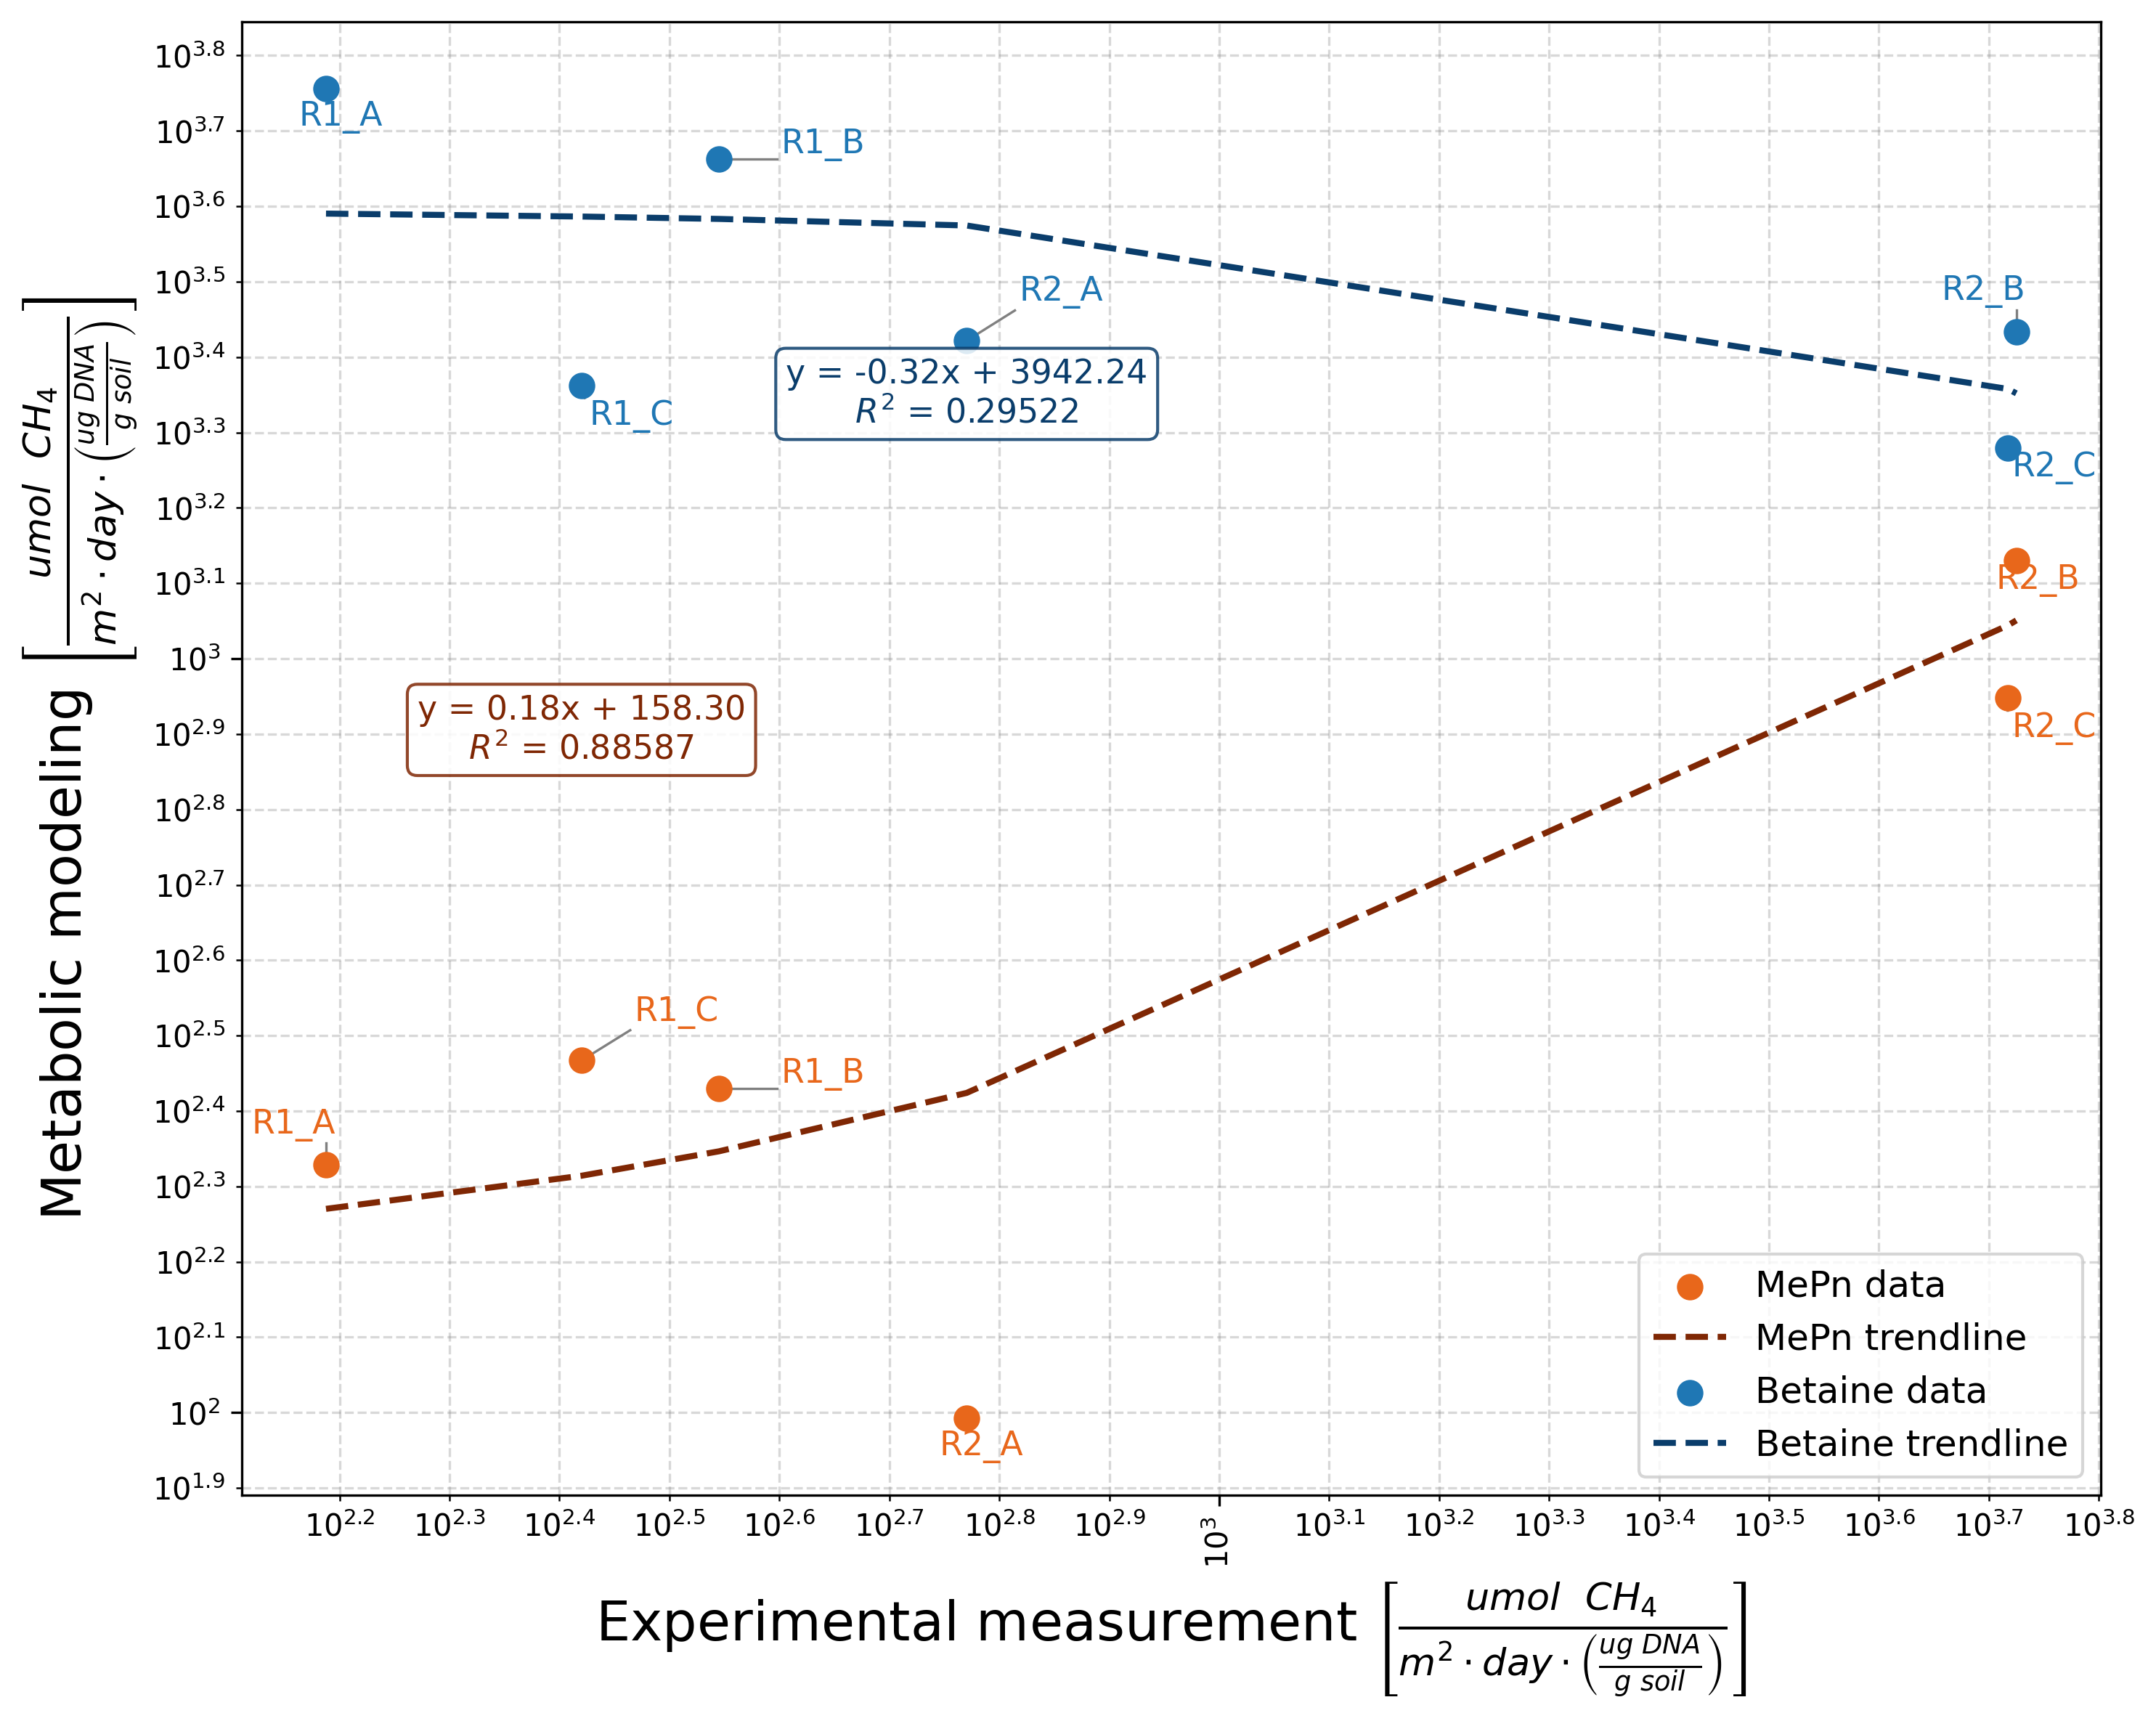

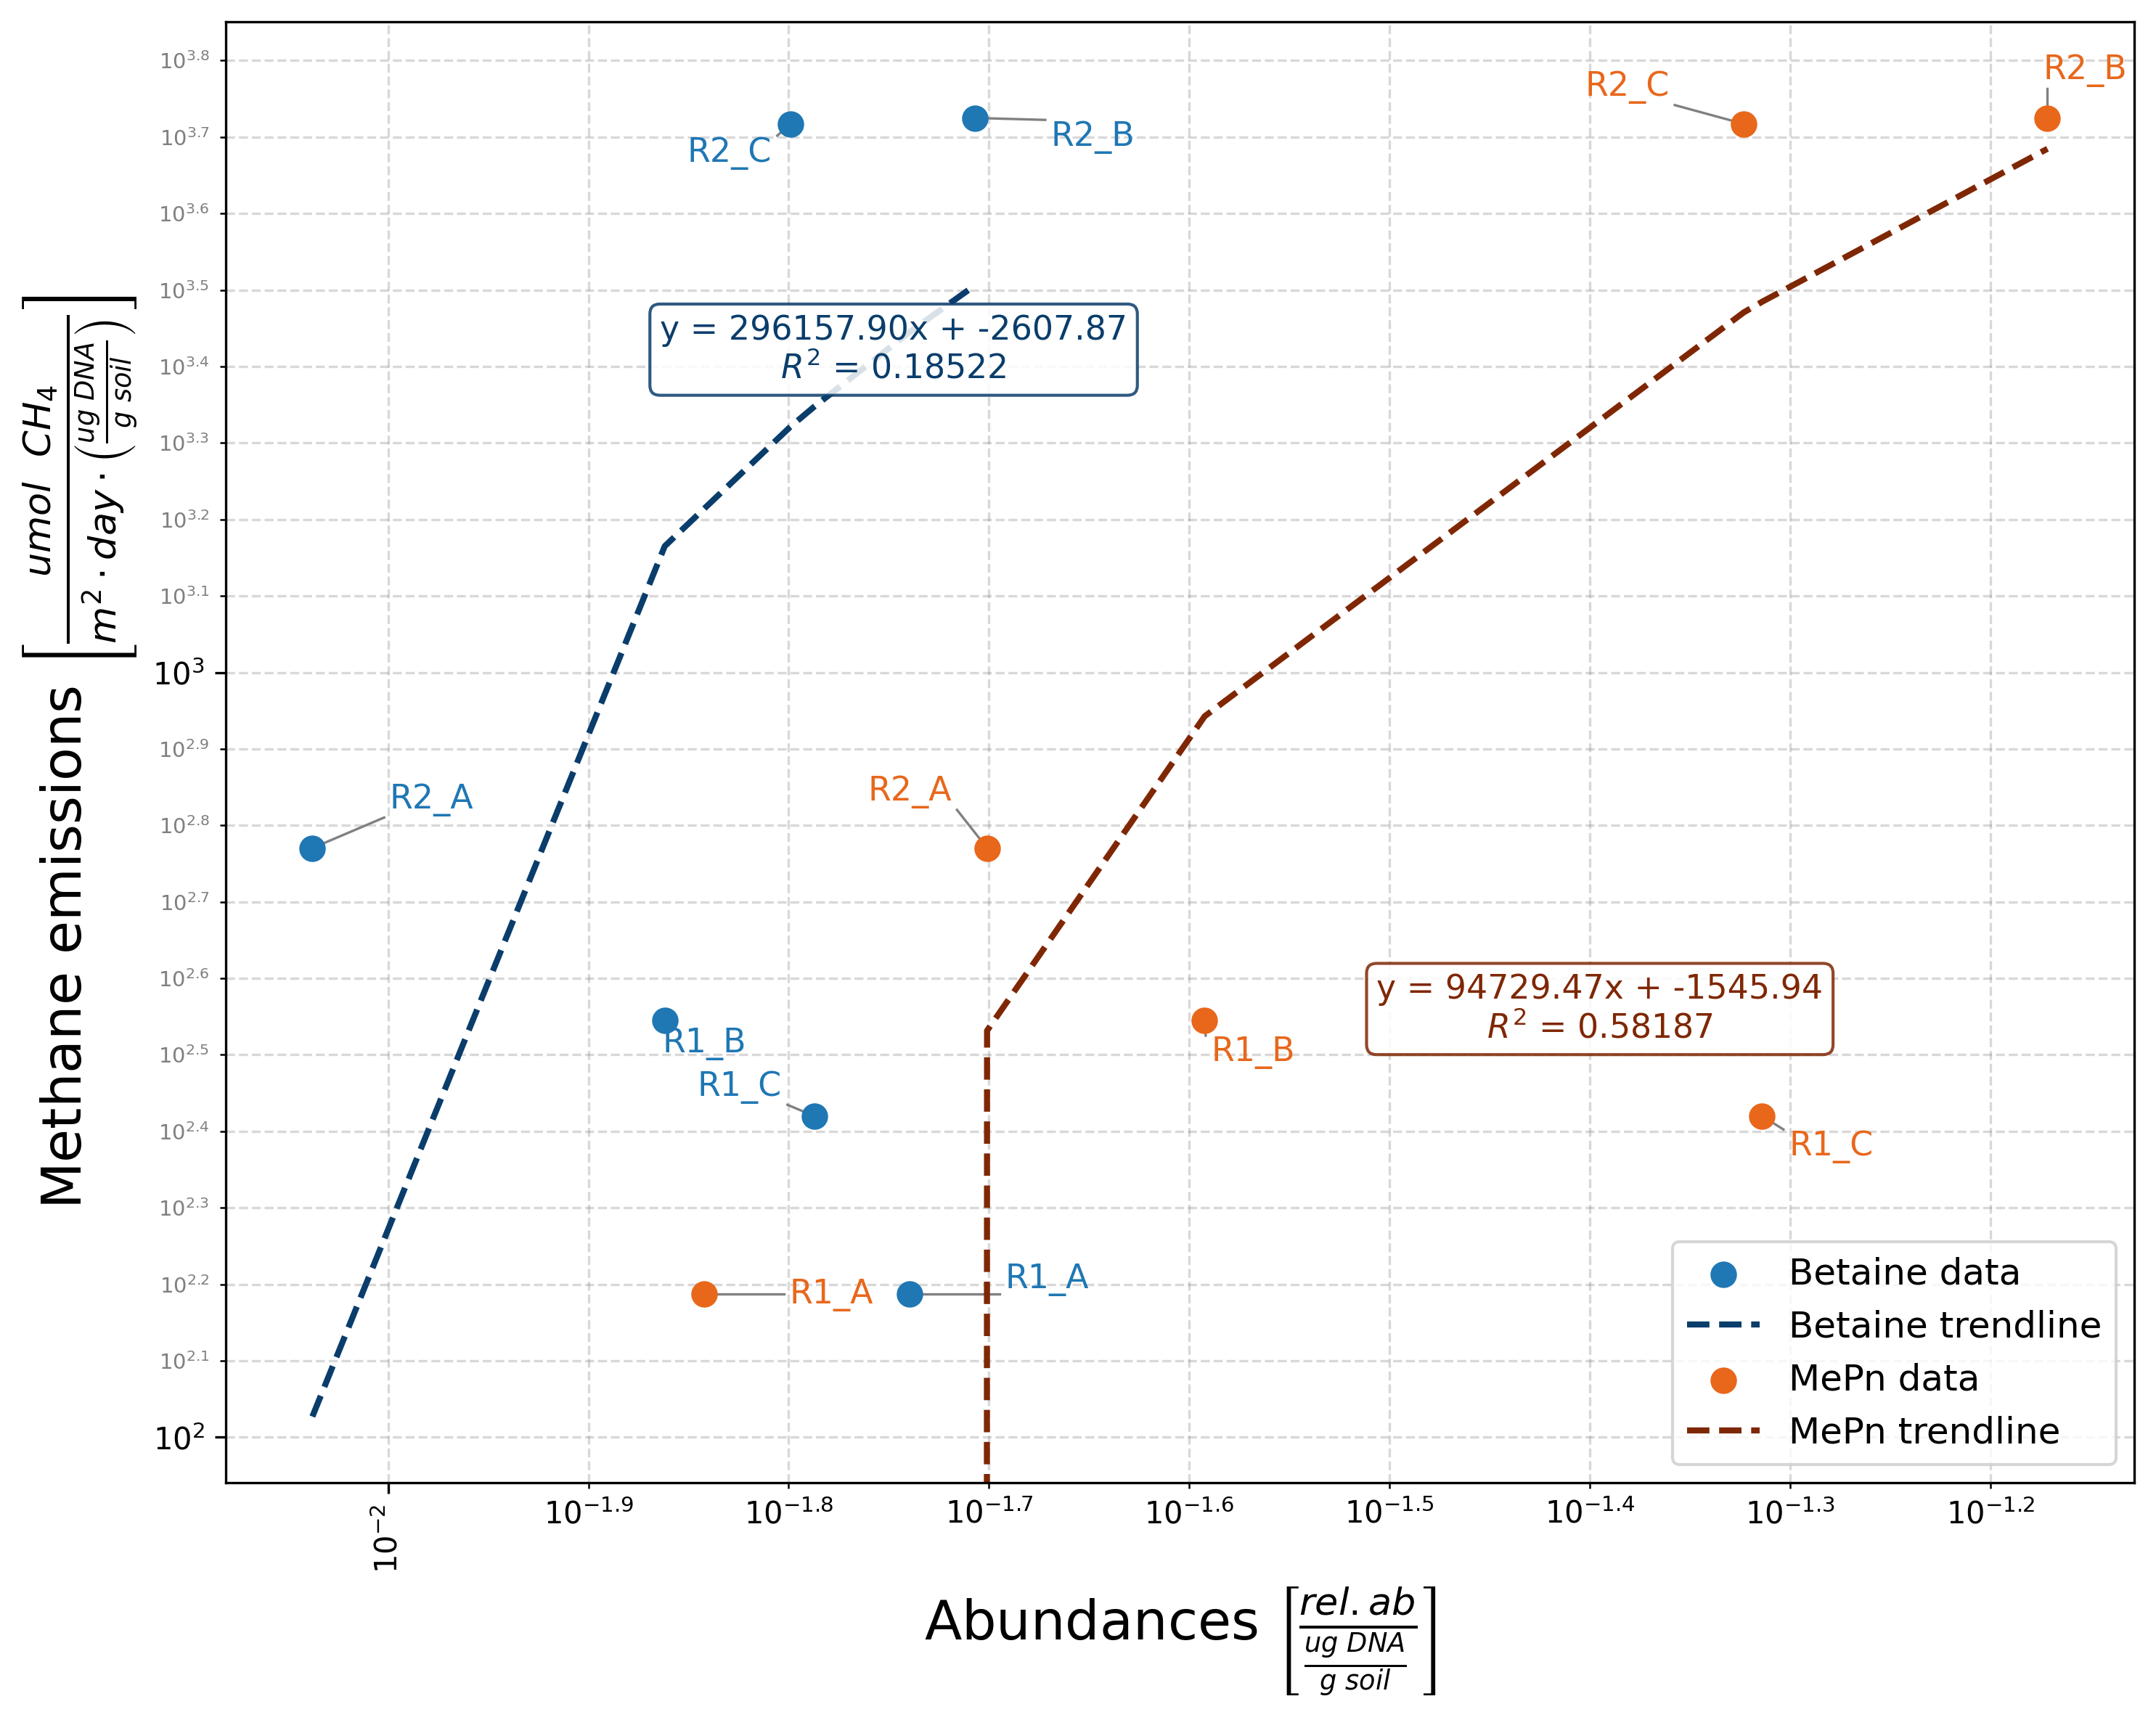

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter
from adjustText import adjust_text
import json
from pandas import DataFrame
from matplotlib.ticker import FuncFormatter

def minor_log_formatter(x, pos):
    exp = np.log10(x)
    if abs(exp - round(exp)) < 1e-9:   # skip positions already covered by major ticks
        return ''
    return f'$10^{{{exp:.1f}}}$'

log = False

files = ['saltern_fluxes.json', 'saltern_fluxes_betaine.json']
palette = [
    {"scatter": "#e8671b", "trendline": "#7f2704", "label": "#e8671b"},
    {"scatter": "#1f77b4", "trendline": "#0a3d6b", "label": "#1f77b4"},
]

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

all_texts   = []
annotations = {}
all_pt_x    = []
all_pt_y    = []

label_size = 11

for fluxes_file, color in zip(files, palette):
    fluxes  = json.load(open(fluxes_file))
    betaine = "betaine" in fluxes_file

    if betaine:
        fluxes_in_emissions = fluxes_to_emissions(DataFrame(fluxes["TMA"]).T.sum()).to_dict()
    else:
        fluxes_in_emissions = fluxes_to_emissions(DataFrame(fluxes["0.07"]["methane"]).T.sum()).to_dict()

    combined = {
        ID: {"fluxes": emissions, "methane": methane_dic[ID]}
        for ID, emissions in fluxes_in_emissions.items()
    }
    combined_df     = DataFrame(combined).T
    methane_ary     = np.array(list(combined_df["methane"].values))
    emission_fluxes = np.array(list(combined_df["fluxes"].values))

    if betaine:
        emission_fluxes = emission_fluxes * 0.06

    xs      = np.array(methane_ary).reshape(-1, 1)
    ys      = np.array(emission_fluxes)
    xs_flat = xs.flatten()
    ys_flat = ys.flatten()
    labels  = list(combined_df.index)

    all_pt_x.extend(xs_flat.tolist())
    all_pt_y.extend(ys_flat.tolist())

    mdl    = LinearRegression()
    mdl.fit(xs, ys)
    y_pred = mdl.predict(xs)

    dataset_label = "Betaine" if betaine else "MePn"

    ax.scatter(xs_flat, ys_flat,
               color=color["scatter"], zorder=3, s=60,
               label=f"{dataset_label} data")

    rng = np.random.default_rng(42)   # fixed seed for reproducibility
    for xi, yi, lbl in zip(xs_flat, ys_flat, labels):
        angle = rng.uniform(0, 2 * np.pi)
        x_off = xi * (1 + 0.15 * np.cos(angle))   # small multiplicative nudge in random direction
        y_off = yi * (1 + 0.15 * np.sin(angle))
        all_texts.append(ax.text(x_off, y_off, lbl,
                                fontsize=label_size, ha='center', va='bottom',
                                color=color["label"], zorder=5))

    sorted_idx = np.argsort(methane_ary)
    ax.plot(xs[sorted_idx].flatten(), y_pred[sorted_idx],
            color=color["trendline"], linestyle='--', linewidth=2,
            label=f"{dataset_label} trendline")

    # Anchor: named point coordinates + trendline prediction AT that x
    anchor_name = "R2_A" if betaine else "R1_C"
    if anchor_name in labels:
        idx           = labels.index(anchor_name)
        anchor_x      = float(xs_flat[idx])
        anchor_y      = float(ys_flat[idx])
        anchor_y_pred = float(mdl.predict([[anchor_x]])[0])
    else:
        idx           = len(labels) // 2
        anchor_x      = float(xs_flat[idx])
        anchor_y      = float(ys_flat[idx])
        anchor_y_pred = float(mdl.predict([[anchor_x]])[0])

    eq      = f"y = {mdl.coef_[0]:.2f}x + {mdl.intercept_:.2f}"
    r2_text = f"$R^2$ = {r2_score(ys, y_pred):.5f}"

    annotations[dataset_label] = dict(
        anchor_x=anchor_x,
        anchor_y_pred=anchor_y_pred,   # trendline value — keeps box on the right line
        eq=eq, r2_text=r2_text, color=color,
        below=betaine
    )

# Log scale + grid
ax.set_xscale('log'); ax.set_yscale('log')
ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10, labelOnlyBase=True))
# ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
# ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
# ax.xaxis.set_minor_formatter(NullFormatter())
# ax.yaxis.set_minor_formatter(NullFormatter())
# Even log-spaced subs: 10^0.1, 10^0.2, ..., 10^0.9 per decade
log_subs = 10 ** np.arange(0.1, 1.0, 0.1)   # [1.26, 1.58, 2.0, 2.51, 3.16, 3.98, 5.01, 6.31, 7.94]

ax.xaxis.set_minor_locator(LogLocator(base=10, subs=log_subs, numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=log_subs, numticks=100))
ax.xaxis.set_minor_formatter(FuncFormatter(minor_log_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(minor_log_formatter))

plt.setp(ax.get_xticklabels(), rotation=90)
ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3)

adjust_text(
    all_texts,
    x=np.array(all_pt_x),
    y=np.array(all_pt_y),
    ax=ax,
    expand_text=(2.0, 2.0),       # was 1.3 — more breathing room between labels
    expand_points=(2.0, 2.0),     # was absent — repel from points too
    force_text=(1.5, 1.5),        # was 0.5 — push labels away from each other harder
    force_points=(1.5, 1.5),      # was 0.3 — push labels away from points harder
    lim=500,                       # more iterations to let it settle
)
fig.canvas.draw()   # <-- NEW: must come after adjust_text so bboxes are settled
renderer = fig.canvas.get_renderer()   # <-- NEW

for txt, xi, yi in zip(all_texts, all_pt_x, all_pt_y):   # <-- NEW block
    bb = txt.get_window_extent(renderer=renderer)
    bb_data = bb.transformed(ax.transData.inverted())
    cx = np.clip(xi, bb_data.x0, bb_data.x1)
    cy = np.clip(yi, bb_data.y0, bb_data.y1)
    ax.plot([cx, xi], [cy, yi],
            color='gray', lw=0.8, zorder=1, clip_on=True)

# Equation boxes anchored to each dataset's OWN trendline at the anchor x
for dataset_label, ann in annotations.items():
    anchor_x      = ann["anchor_x"]
    anchor_y_pred = ann["anchor_y_pred"]   # on the trendline, not the scatter point
    color         = ann["color"]

    if ann["below"]:
        # Betaine (flat, high): box just below the trendline value at R2_A
        text_y = anchor_y_pred / 1.5
        va     = "top"
    else:
        # MePn (steep, low at R1_C): box just above the trendline value at R1_C
        text_y = anchor_y_pred * 3.5
        va     = "bottom"

    ax.text(
        anchor_x, text_y,
        ann["eq"] + "\n" + ann["r2_text"],
        fontsize=label_size,
        color=color["trendline"],
        ha='center', va=va,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  alpha=0.85, edgecolor=color["trendline"]),
        zorder=6
    )

axes_size = 18
ax.set_xlabel(r'Experimental measurement $\left[\frac{umol~~CH_4}{m^2 \cdot day \cdot \left(\frac{ug~DNA}{g~soil}\right)}\right]$', fontsize=axes_size)
ax.set_ylabel(r'Metabolic modeling $\left[\frac{umol~~CH_4}{m^2 \cdot day \cdot \left(\frac{ug~DNA}{g~soil}\right)}\right]$', fontsize=axes_size)
# ax.set_title(
#     r"Methane emissions $\left[\frac{umol~~CH_4}{m^2 \cdot day \cdot \left(\frac{ug~DNA}{g~soil}\right)}\right]$",
#     fontsize=axes_size + 2
# )
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()
fig.savefig("combined_experiment_modeling.png", bbox_inches='tight')
fig.show()





from matplotlib.ticker import FuncFormatter

def minor_log_formatter(x, pos):
    exp = np.log10(x)
    if abs(exp - round(exp)) < 1e-9:
        return ''
    return f'$10^{{{exp:.1f}}}$'

log_subs = 10 ** np.arange(0.1, 1.0, 0.1)

palette = [
    {"scatter": "#1f77b4", "trendline": "#0a3d6b", "label": "#1f77b4"},   # Blue
    {"scatter": "#e8671b", "trendline": "#7f2704", "label": "#e8671b"},    # Orange
]

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

all_texts = []
all_pt_x  = []
all_pt_y  = []
annotations = {}

rng = np.random.default_rng(42)
linear = True
for samples, color in zip(["Betaine", "MePn"], palette):
    if samples == "MePn":
        sample_totals = averaged_unrestored_normalized_abundances.loc[list(mepe_striped)].sum()
    else:
        sample_totals = averaged_unrestored_normalized_abundances.loc[list(betaine_striped)].sum()

    all_xs = np.array(sample_totals.to_list())
    xs     = all_xs.reshape(-1, 1)
    all_ys = averaged_unrestored_normalized_methane.to_list()
    ys     = np.array(all_ys)

    xs_flat = all_xs.flatten()
    ys_flat = ys.flatten()
    labels  = list(sample_totals.index)

    all_pt_x.extend(xs_flat.tolist())
    all_pt_y.extend(ys_flat.tolist())

    if linear:
        model = LinearRegression()
        model.fit(xs, ys)
        y_pred    = model.predict(xs)
        coef      = model.coef_[0]
        intercept = model.intercept_
    else:
        poly  = PolynomialFeatures(degree=2, include_bias=False)
        lin   = LinearRegression()
        model = Pipeline([("poly", poly), ("lin", lin)])
        model.fit(xs, ys)
        y_pred     = model.predict(xs)
        term_names = model.named_steps["poly"].get_feature_names_out()
        coef       = model.named_steps["lin"].coef_
        intercept  = model.named_steps["lin"].intercept_

    # Scatter
    ax.scatter(xs_flat, ys_flat,
               color=color["scatter"], zorder=3, s=60,
               label=f"{samples} data")

    # Labels with random angular offset
    for xi, yi, lbl in zip(xs_flat, ys_flat, labels):
        angle = rng.uniform(0, 2 * np.pi)
        x_off = xi * (1 + 0.15 * np.cos(angle))
        y_off = yi * (1 + 0.15 * np.sin(angle))
        all_texts.append(ax.text(x_off, y_off, lbl,
                                 fontsize=label_size, ha='center', va='bottom',
                                 color=color["label"], zorder=5))

    # Trendline
    sorted_idx = np.argsort(all_xs)
    ax.plot(all_xs[sorted_idx], y_pred[sorted_idx],
            color=color["trendline"], linestyle='--', linewidth=2,
            label=f"{samples} trendline")

    # Equation
    if linear:
        eq = f"y = {coef:.2f}x + {intercept:.2f}"
    else:
        precision = 4
        parts = [f"{intercept:.{precision}g}"]
        for c, t in zip(coef, term_names):
            sign = " + " if c >= 0 else " - "
            parts.append(f"{sign}{abs(c):.{precision}g}*{t}")
        eq = "y = " + "".join(parts)
    r2_text = f"$R^2$ = {r2_score(all_ys, y_pred):.5f}"

    # Anchor box to midpoint of trendline
    mid_idx       = len(sorted_idx) // 2
    anchor_x      = float(all_xs[sorted_idx][mid_idx])
    anchor_y_pred = float(y_pred[sorted_idx][mid_idx])

    annotations[samples] = dict(
        anchor_x=anchor_x,
        anchor_y_pred=anchor_y_pred,
        eq=eq, r2_text=r2_text, color=color,
        below=(samples == "Betaine")
    )

# Log scale + grid
ax.set_xscale('log'); ax.set_yscale('log')
ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=log_subs, numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=log_subs, numticks=100))
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.xaxis.set_minor_formatter(FuncFormatter(minor_log_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(minor_log_formatter))
plt.setp(ax.get_xticklabels(), rotation=90)
plt.setp(ax.get_yticklabels(minor=True), fontsize=7, color='gray')
ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3)

adjust_text(
    all_texts,
    x=np.array(all_pt_x),
    y=np.array(all_pt_y),
    ax=ax,
    expand_text=(2.0, 2.0),
    expand_points=(2.0, 2.0),
    force_text=(1.5, 1.5),
    force_points=(1.5, 1.5),
    lim=500,
)

# Lines from label edge to point
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
for txt, xi, yi in zip(all_texts, all_pt_x, all_pt_y):
    bb      = txt.get_window_extent(renderer=renderer)
    bb_data = bb.transformed(ax.transData.inverted())
    cx      = np.clip(xi, bb_data.x0, bb_data.x1)
    cy      = np.clip(yi, bb_data.y0, bb_data.y1)
    ax.plot([cx, xi], [cy, yi],
            color='gray', lw=0.8, zorder=1, clip_on=True)

# Equation boxes in axes coordinates (0-1 range, bottom-left origin)
box_positions = {
    "MePn":    dict(x=0.72, y=0.3, va="bottom"),   # bottom-right, just above legend
    "Betaine": dict(x=0.35, y=0.8, va="top"),       # top-right, same level as old MePn
}
for samples, ann in annotations.items():
    color = ann["color"]
    pos   = box_positions[samples]

    ax.text(pos["x"], pos["y"],
            ann["eq"] + "\n" + ann["r2_text"],
            fontsize=label_size, color=color["trendline"],
            ha='center', va=pos["va"],
            transform=ax.transAxes,                        # <-- axes coords, not data coords
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      alpha=0.85, edgecolor=color["trendline"]),
            zorder=6)

axes_size = 18
ax.set_xlabel(r'Abundances $\left[\frac{rel.ab}{\frac{ug~DNA}{g~soil}}\right]$', fontsize=axes_size)
ax.set_ylabel(r'Methane emissions $\left[\frac{umol~~CH_4}{m^2 \cdot day \cdot \left(\frac{ug~DNA}{g~soil}\right)}\right]$', fontsize=axes_size)
# ax.set_title('Consumer abundance vs. methane emissions', fontsize=axes_size + 2)
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()
fig.savefig("consumers_combined.png", bbox_inches='tight')
fig.show()

In [49]:
# Grab the metabolite by ID

for ID, content in sols.items():
    model = models[ID]
    try:
        print(list(model.metabolites)[0])
        met = model.metabolites.get_by_id("cpd01024_c0")  # e.g., D-glucose
    except KeyError:
        print(f"Metabolite cpd01024_c0 not found in model {ID}")
        continue
    metReactions = [rxn.id for rxn in met.reactions]
    for sample, sol in content.items():
        methane_flux = fluxes["methane"][ID][sample]
        if methane_flux == 0:   continue
        tma_flux = fluxes["TMA"][ID][sample]
        betaine_flux = fluxes["betaine"][ID][sample]
        lactate_flux = fluxes["lactate"][ID][sample]
        print(ID, sample)
        print(methane_flux, tma_flux, betaine_flux, lactate_flux)
        
        for rxn in metReactions:
            flux = sol.fluxes[rxn]
            stoich = sol.model.reactions.get_by_id(rxn).metabolites[met]  # stoichiometric coefficient
            print(f"{rxn}: stoich={stoich:+.2f}, flux={flux:.4f}")
        non_zero_fluxes = {k:f for k,f in sol.fluxes.to_dict().items() if f != 0}
        # betaine_fluxes = sol.fluxes
        # display(betaine_fluxes)
        break
    break

cpd00012_c0
Metabolite cpd01024_c0 not found in model Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs
cpd00012_c0
Metabolite cpd01024_c0 not found in model Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs
cpd00012_c0
Metabolite cpd01024_c0 not found in model Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs
cpd00443_c0
Metabolite cpd01024_c0 not found in model Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs
cpd00443_c0
Metabolite cpd01024_c0 not found in model Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs
cpd00012_c0
Metabolite cpd01024_c0 not found in model Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs
cpd00012_c0
Metabolite cpd01024_c0 not found in model Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs
cpd00443_c0
Metabolite cpd01024_c0 not found in model Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs
cpd00443_c0
Metabolite cpd01024_c0 not found in model Salt_Pond_MetaG_R1_B_D1_MG_DASTool_

##### Claude updated visualization

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter
import numpy as np
import json
from pandas import DataFrame, read_csv, Series
from math import pi
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import r2_score
from adjustText import adjust_text

def fluxes_to_emissions(row):
    area_cm2 = pi * (5/2)**2
    area_m2 = area_cm2 * (1e-2)**2
    volume_cm3 = 294.52
    ugDNA_gSoil = 2
    DNA_per_biomass = 0.1
    gSoil_cm3 = 1.4
    gBiomass_gSoil = gSoil_cm3 * volume_cm3 * ugDNA_gSoil / DNA_per_biomass / 1000 / 1000
    return row / area_m2 * 1e3 * 24 * (gBiomass_gSoil)

methane_dic = json.load(open("averaged_normalized_methane_unrestored.json"))
averaged_unrestored_normalized_abundances = read_csv("averaged_normalized_abundances_unrestored.csv", index_col=0)
averaged_unrestored_normalized_methane = Series(methane_dic)

betaine = {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs',
'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs',
'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs',
'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs',
'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs',
'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs',
'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs',
'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs',
'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs',
'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs',
'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs',
'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs',
'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs',
'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs'}
betaine_striped = [x.replace(".contigs","") for x in betaine]

mepe = {'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs',
'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs',
'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs',
'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs',
'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs',
'Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs',
'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs',
'Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs',
'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs',
'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs',
'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14.contigs',
'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.143.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.10.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.16.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs',
'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs',
'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs',
'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs',
'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs',
'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.47.contigs',
'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs',
'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'}
mepe_striped = [x.replace(".contigs","") for x in mepe]

log = False
linear = True

# === FIRST PLOT SECTION: flux vs methane correlations ===
for fluxes_file in ['saltern_fluxes.json', 'saltern_fluxes_betaine.json']:
    fluxes = json.load(open(fluxes_file))

    # Handle different file structures
    if "0.07" in fluxes:
        flux_groups = {"methane": fluxes["0.07"]["methane"]}
    else:
        flux_groups = fluxes

    for flux_type, flux_data in flux_groups.items():
        summed = DataFrame(flux_data).T.sum().abs()
        fluxes_in_emissions = fluxes_to_emissions(summed).to_dict()

        combined = {ID: {"fluxes": em, "methane": methane_dic[ID]}
                    for ID, em in fluxes_in_emissions.items() if ID in methane_dic}
        combined_df = DataFrame(combined).T
        methane_ary = np.array(list(combined_df["methane"].values))
        emission_fluxes = np.array(list(combined_df["fluxes"].values))

        fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
        xs = methane_ary.reshape(-1, 1)
        ys = emission_fluxes

        if log:
            xs = np.log(xs)
            ys = np.log(ys)
            title = r"Methane emissions $\left[LOG\left(\frac{umol~~CH_4}{m^2*day*\left(\frac{ug DNA}{g soil}\right)}\right)\right]$"
        else:
            ax.set_xscale('log'); ax.set_yscale('log')
            ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
            ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
            ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
            ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
            fmt = LogFormatterMathtext(base=10, labelOnlyBase=True)
            ax.xaxis.set_major_formatter(fmt)
            ax.yaxis.set_major_formatter(fmt)
            ax.xaxis.set_minor_formatter(NullFormatter())
            ax.yaxis.set_minor_formatter(NullFormatter())
            plt.setp(ax.get_xticklabels(), rotation=90)
            title = f"{flux_type.capitalize()} flux correlation"

        mdl = LinearRegression()
        mdl.fit(xs, ys)
        ax.scatter(xs.flatten(), ys)
        ax.grid(True, which='both', axis='both', linestyle='--', color='gray', alpha=0.3)
        label_size = 13
        texts = []
        for xi, yi, label in zip(xs.flatten(), ys, list(combined_df.index)):
            texts.append(ax.text(xi, yi, label, fontsize=label_size, ha='center', va='bottom'))
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='gray'))

        y_pred = mdl.predict(xs)
        trendline_color = "green"
        sorted_idx = np.argsort(methane_ary)
        ax.plot(xs.flatten()[sorted_idx], y_pred[sorted_idx], color=trendline_color, linestyle='--', label='Trendline')

        eq = f"y = {mdl.coef_[0]:.2f}x + {mdl.intercept_:.2f}"
        r2_text = f"$R^2$ = {r2_score(ys, y_pred):.5f}"
        ax.text(0.3, 0.8, eq + '\n' + r2_text, transform=ax.transAxes, fontsize=label_size, color=trendline_color, verticalalignment='top')

        axes_size = 20
        ax.set_xlabel('Experimental measurement', fontsize=axes_size)
        ax.set_ylabel('Metabolic modeling (|flux|)', fontsize=axes_size)
        ax.set_title(title, fontsize=axes_size+4)
        plt.tight_layout()
        fname = f"experiment_modeling_{fluxes_file.replace('.json','')}_{flux_type}.png"
        fig.savefig(fname)
        plt.close(fig)
        print(f"Saved {fname}: R2={r2_score(ys, y_pred):.5f}")


# === SECOND PLOT SECTION: abundance vs methane correlations ===
for samples in ["MePn", "Betaine"]:
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    if samples == "MePn":
        sample_totals = averaged_unrestored_normalized_abundances.loc[list(mepe_striped)].sum()
        title = 'MePn consumer correlation'
        export_name = "MePn_consumers_new.png"
    else:
        sample_totals = averaged_unrestored_normalized_abundances.loc[list(betaine_striped)].sum()
        title = 'Betaine consumer correlation'
        export_name = "Betaine_consumers_new.png"

    all_xs = np.array(sample_totals.to_list())
    xs = all_xs.reshape(-1, 1)
    all_ys = averaged_unrestored_normalized_methane.to_list()
    ys = np.array(all_ys)

    if log:
        xs = np.log(xs)
        ys = np.log(ys)
        ax.set_xlabel(r'Abundances $\left[LOG\left(\frac{rel.ab}{\frac{ug DNA}{g soil}}\right)\right]$', fontsize=20)
        ax.set_ylabel(r"Methane emissions $\left[LOG\left(\frac{umol~~CH_4}{m^2*day*\left(\frac{ug DNA}{g soil}\right)}\right)\right]$", fontsize=20)
    else:
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
        ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
        ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
        fmt = LogFormatterMathtext(base=10, labelOnlyBase=True)
        ax.xaxis.set_major_formatter(fmt)
        ax.yaxis.set_major_formatter(fmt)
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.yaxis.set_minor_formatter(NullFormatter())
        plt.setp(ax.get_xticklabels(), rotation=90)
        ax.set_xlabel(r'Abundances $\left[\left(\frac{rel.ab}{\frac{ug DNA}{g soil}}\right)\right]$', fontsize=20)
        ax.set_ylabel(r"Methane emissions $\left[\left(\frac{umol~~CH_4}{m^2*day*\left(\frac{ug DNA}{g soil}\right)}\right)\right]$", fontsize=20)

    if linear:
        model = LinearRegression()
        model.fit(xs, ys)
        y_pred = model.predict(xs)
        coef = model.coef_[0]
        intercept = model.intercept_
    else:
        poly = PolynomialFeatures(degree=2, include_bias=False)
        lin = LinearRegression()
        model = Pipeline([("poly", poly), ("lin", lin)])
        model.fit(xs, ys)
        y_pred = model.predict(xs)
        term_names = model.named_steps["poly"].get_feature_names_out()
        coef = model.named_steps["lin"].coef_
        intercept = model.named_steps["lin"].intercept_

    ax.scatter(all_xs, ys)
    label_size = 13
    texts = []
    for xi, yi, label in zip(all_xs, ys, list(sample_totals.index)):
        texts.append(ax.text(xi, yi, label, fontsize=label_size, ha='center', va='bottom'))
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='gray'))

    sorted_idx = np.argsort(all_xs)
    sorted_xs = all_xs[sorted_idx]
    sorted_ys = y_pred[sorted_idx]
    trendline_color = "green"
    ax.plot(sorted_xs, sorted_ys, color=trendline_color, linestyle='--', label='Trendline')
    ax.grid(True, which='both', axis='both', linestyle='--', color='gray', alpha=0.3)

    if linear:
        eq = f"y = {coef:.2f}x + {intercept:.2f}"
    else:
        precision = 4
        parts = [f"{intercept:.{precision}g}"]
        for c, t in zip(coef, term_names):
            sign = " + " if c >= 0 else " - "
            parts.append(f"{sign}{abs(c):.{precision}g}*{t}")
        eq = "y = " + "".join(parts)
    r2_text = f"$R^2$ = {r2_score(all_ys, y_pred):.3f}"

    ax.text(0.2, 0.7, eq + '\n' + r2_text, transform=ax.transAxes, fontsize=label_size, color=trendline_color, verticalalignment='top')
    axes_size = 20
    ax.set_title(title, fontsize=axes_size+4)
    plt.tight_layout()
    fig.savefig(export_name)
    plt.close(fig)
    print(f"Saved {export_name}")

print("\nDone!")

# heatmap co-occurrence assessment

## IterativeIDs

In [124]:
from pandas import read_csv
from json import load, dump

phylogeny = load(open("../data/Saltern_phylogeny.json"))
# phylogeny = read_csv("../data/Saltern_phylogeny.csv")
# phylogeny = dict(zip(phylogeny["User Genome"], phylogeny["Classification"]))

# create an iterative counted name for each ASV according to redundant Genuses
iterativeIDs, iterativeID_levels, iterativeID_phylums = {}, {}, {}

for MAG, taxa in phylogeny.items():
    best_level = "Kingdom"
    # print(MAG, taxa)
    for level, taxon in taxa.items():
        # print(level, taxon)
        if not isinstance(taxon, str) or level == "Species" or taxon == "":
            break
        best_level = level
    # if not isinstance(genus, str):  continue
    taxon = taxa[best_level]
    # print(best_level, taxon)
    taxon += ".1"
    while taxon in iterativeIDs:
        taxon, count = taxon.split(".")
        taxon = f"{taxon}.{int(count)+1}"
    # print(genus)
    iterativeIDs[taxon] = MAG.replace(".contigs__", '')
    iterativeID_levels[taxon] = best_level
    iterativeID_phylums[taxon] = taxa["Phylum"]

# iterativeIDs = {ASV: taxa["Genus"] + "_" + str(Counter(ASV_genera.values()).most_common().index(taxa["Genus"])) for ASV, taxa in midas_taxonomy.items()}
iterativeIDs = {v:k for k,v in iterativeIDs.items()}
display(list(iterativeIDs.items())[:5])
display(list(iterativeID_levels.items())[:5])
display(list(iterativeID_phylums.items())[:5])
dump(iterativeIDs, open("iterativeIDs.json", 'w'))
dump(iterativeID_levels, open("iterativeID_levels.json", 'w'))
dump(iterativeID_phylums, open("iterativeID_phylums.json", 'w'))
print("None taxonomy entries:", [k for k, v in iterativeID_phylums.items() if v is None])

betaine = {'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9.contigs',
'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.47.contigs',
'Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.51.contigs',
'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.27.contigs',
'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.45.contigs',
'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.48.contigs',
'Salt_Pond_MetaG_R1_A_D2_MG_DASTool_bins_metabat.50.contigs',
'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_concoct_out.59.contigs',
'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.58.contigs',
'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.73.contigs',
'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_maxbin.047.contigs',
'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_concoct_out.85.contigs',
'Salt_Pond_MetaG_R1_C_D2_MG_DASTool_bins_metabat.40.contigs',
'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.98.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.52.contigs'}
betaine_iterativeIDs = [iterativeIDs[x.replace(".contigs","")] for x in betaine]
display(betaine_iterativeIDs)

mepe = {'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs',
'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs',
'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs',
'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs',
'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs',
'Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs',
'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs',
'Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs',
'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs',
'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs',
'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14.contigs',
'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.143.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.10.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.16.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs',
'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs',
'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs',
'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs',
'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs',
'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs',
'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.47.contigs',
'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs',
'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'}
mepe_iterativeIDs = [iterativeIDs.get(x.replace(".contigs",""), x.replace(".contigs","")) for x in mepe]
display(mepe_iterativeIDs)

[('Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.44', 'SZUA-401.1'),
 ('Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.54',
  'Thiohalorhabdus.1'),
 ('Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.concoct_out.9', 'UBA8670.1'),
 ('Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.15', 'Fodinibius.1'),
 ('Salt_Pond_MetaG_R1_A_D1_MG_DASTool_bins.metabat.18', 'YR4-1.1')]

[('SZUA-401.1', 'Family'),
 ('Thiohalorhabdus.1', 'Genus'),
 ('UBA8670.1', 'Genus'),
 ('Fodinibius.1', 'Genus'),
 ('YR4-1.1', 'Genus')]

[('SZUA-401.1', 'Desulfobacterota_F'),
 ('Thiohalorhabdus.1', 'Proteobacteria'),
 ('UBA8670.1', 'Firmicutes_A'),
 ('Fodinibius.1', 'Bacteroidota'),
 ('YR4-1.1', 'Bacteroidota')]

None taxonomy entries: []


['UBA8670.2',
 'Synergistales.2',
 'Halanaerobiales.4',
 'Halanaerobiales.1',
 'BM714.1',
 'Acidaminobacteraceae.1',
 'BM714.2',
 'Halanaerobium.2',
 'Halanaerobium.1',
 'BM714.3',
 'UBA8670.1',
 'Halanaerobiales.3',
 'BM714.4',
 'Halanaerobium.3',
 'Synergistales.1']

['Roseovarius.6',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16',
 'Roseovarius.12',
 'Salinarimonas.1',
 'Roseovarius.10',
 'Roseovarius.2',
 'Desulfotignum.2',
 'Roseicyclus.2',
 'Phaeodactylibacter.1',
 'Roseovarius.9',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14',
 'Roseicyclus.1',
 'Roseovarius.5',
 'Marivita.3',
 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31',
 'Roseovarius.11',
 'Roseovarius.1',
 'Thiolinea.1',
 'Albimonas.1',
 'Roseovarius.7',
 'Roseovarius.8',
 'Marivita.2',
 'UBA6960.1',
 'Maliponia.1',
 'Roseovarius.4',
 'Desulfotignum.1',
 'IMCC34051.1']

In [101]:
from pandas import read_csv
from matplotlib import colors, pyplot, patches
from matplotlib.patches import Patch
from pandas import Series, DataFrame
from numpy import ones, triu, nan, ones_like
import seaborn as sns
from json import load
from statsmodels.stats.multitest import multipletests
from scipy.stats import spearmanr
from collections import defaultdict
from itertools import combinations
import numpy as np


def corr_pvalues(df):
    n = df.shape[1]
    pvals = DataFrame(ones((n, n)), index=df.columns, columns=df.columns)
    corrs = DataFrame(ones((n, n)), index=df.columns, columns=df.columns)
    for i in range(n):
        for j in range(i+1, n):
            c, p = spearmanr(df.iloc[:, i], df.iloc[:, j])
            pvals.iloc[i, j] = p
            corrs.iloc[i, j] = c
            pvals.iloc[j, i] = p
            corrs.iloc[j, i] = c
    return pvals, corrs

def merge_depths_by_DNA(abundances):
    return DataFrame({prefix: (abundances[prefix+"_D1"]*sample_dna[prefix+"_D1"] + abundances[prefix+"_D2"]*sample_dna[prefix+"_D2"]) / (sample_dna[prefix+"_D1"] + sample_dna[prefix+"_D2"])
                    for prefix in unique_prefixes}, index=abundances.index)

def merge_triplicates(abundances):
    # print("here", (abundances["R2_A"] + abundances["R2_B"] + abundances["R2_C"]) / 3)
    return DataFrame({site: (abundances[site+"_A"] + abundances[site+"_B"] + abundances[site+"_C"]) / 3
                    for site in sites}, index=abundances.index)

dna_df = read_csv("../data/SaltPondsDNA.csv").set_index("Sample")
sample_dna = dna_df["DNA conc (µg/g soil)"].to_dict()
iterativeIDs = load(open("iterativeIDs.json", 'r'))
iterativeID_levels = load(open("iterativeID_levels.json", 'r'))
iterativeID_taxonomy = {iterativeIDs.get(ID, ID): phylogeny.get(ID, "Unknown") for ID in iterativeIDs}
unique_prefixes = {"_".join(i.split("_")[:-1]) for i in dna_df.index}
sites = {i.split("_")[0] for i in unique_prefixes}
volume_weighted_sample_dna = Series({
    prefix: (5*sample_dna[prefix+"_D1"] + 10*sample_dna[prefix+"_D2"]) / 15
    for prefix in unique_prefixes                                                                                                                                          
})

abundances = merge_depths_by_DNA(read_csv("../data/Cliff_310MAG_relabund.tsv", sep="\t"))
# display(df)
abundances = merge_triplicates(abundances).T
# display(df)
zero_level = 1e-5
abundances = abundances.loc[:, (abundances.fillna(0) > zero_level).sum() >= 3]
abundances.columns = [iterativeIDs.get(ID, ID) for ID in abundances.columns] #columns
display(abundances)
df = abundances
iterativeID_phylums = {ID: v for ID,v in iterativeID_phylums.items() if ID in df.columns}

reduced = True
if reduced:
    reduced_abundances = abundances.copy()
    reduced_abundances.columns = [".".join(ID.split(".")[:-1]) for ID in reduced_abundances.columns] #columns
    reduced_abundances = reduced_abundances.groupby(reduced_abundances.columns, axis=1).sum()
    display(reduced_abundances)
    df = reduced_abundances
    iterativeID_phylums = {".".join(ID.split(".")[:-1]): v for ID,v in iterativeID_phylums.items()}

# for df in [abundances, reduced_abundances]:
pval_matrix, corr_matrix = corr_pvalues(df)
display(corr_matrix)

# BH-FDR correction
presence = (df > zero_level).astype(int)
cooccurrence = defaultdict(int)
for sample in presence.itertuples(index=False):
    present = [col for col, val in zip(presence.columns, sample) if val]
    for pair in combinations(sorted(present), 2):
        cooccurrence[pair] += 1

# --- 2. Pass 1: run Spearman on every qualifying pair, keep results in memory
pair_data = []   # each entry: (a, b, rho, p_value, count)
for (a, b), count in cooccurrence.items():
    rho = corr_matrix.loc[a, b]
    if np.isnan(rho): continue
    p_value = pval_matrix.loc[a, b]
    pair_data.append((a, b, rho, p_value, count))

# --- 3. Pass 2: BH-FDR correction across all tests actually run
pvals = np.array([t[3] for t in pair_data])
np.savetxt("pvals.txt", pvals)
reject, qvals, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
print(len(pvals), sum(reject))

# create taxonomically-labeled colors
level = "Phylum"
orgs = set()
for (a, b, _, _, _), take in zip(pair_data, reject):
    if take:
        orgs.add(a)
        orgs.add(b)
# display(orgs)
dump(list(orgs), open("significantly_connected_organisms.json", 'w'))

# Determine the phylum-level colorings
# --- Separate archaea and bacteria phyla
archaea_phyla = sorted({phylum for phylum in iterativeID_phylums.values() 
                        if phylum and (
                            "archaeo" in phylum.lower() or 
                            any(a in phylum.lower() for a in [
                                "candidatus thermoplasmatota", "halobacterota", "methanobacteriota", "micrarchaeota"
                            ])
                        )})
# print(archaea_phyla)
bacteria_phyla = sorted({phylum for phylum in iterativeID_phylums.values() if phylum and phylum not in archaea_phyla})
# print(bacteria_phyla)

# Archaea: red end of spectrum (0.0 - 0.15 in turbo)
n_archaea = len(archaea_phyla)
archaea_colors = [pyplot.cm.turbo(i / max(n_archaea, 1) * 0.15) for i in range(n_archaea)]
# Bacteria: rest of spectrum (0.2 - 1.0 in turbo)
n_bacteria = len(bacteria_phyla)
bacteria_colors = [pyplot.cm.turbo(0.2 + i / max(n_bacteria, 1) * 0.8) for i in range(n_bacteria)]
# print(bacteria_colors)
# Combine into one color map
taxa_color_map = {}
for phylum, color in zip(archaea_phyla, archaea_colors):
    taxa_color_map[phylum] = color
for phylum, color in zip(bacteria_phyla, bacteria_colors):
    taxa_color_map[phylum] = color
dump(taxa_color_map, open(f"{level}_color_map.json", "w"))
# display(list(taxa_color_map.items())[:5])
iterativeID_color_map = {ID: taxa_color_map[phylum] for ID, phylum in iterativeID_phylums.items() if phylum}
dump(iterativeID_color_map, open(f"iterativeID_color_map.json", "w"))
# display(list(iterativeID_color_map.items())[:5])
                                                                                                            
DEFAULT_COLOR = "lightgray"         
bar_label = "Phylum"  
row_colors = Series({idx: iterativeID_color_map.get(idx, DEFAULT_COLOR) for idx in corr_matrix.index}, name=bar_label)                                                                                                                                                            
col_colors = Series({col: iterativeID_color_map.get(col, DEFAULT_COLOR) for col in corr_matrix.columns}, name=bar_label)
display(row_colors[:5])

,Thiohalobacterales.2,Balneolales.1,Halioglobus.2,M0040.2,Yeosuana.1,UBA12270.1,Balneolaceae.6,UBA11386.1,UBA10428.1,Salt_Pond_MetaGSF2_C_D2_MG_DASTool_bins_concoct_out.25,...,KS3-K002.1,Thiohalomonadales.1,Halofilum.1,Balneolaceae.4,Thiohalophilus.1,Halofilum.2,Alphaproteobacteria.1,Balneolaceae.5,S36-B12.3,unbinned_reads
SF2,0.000867,0.002511,0.002212,0.008691,0.001778,0.002161,0.001174,0.001026,0.002170,0.001031,...,0.000233,0.000087,0.000200,0.000079,0.000057,0.000087,0.000452,0.000694,0.000003,0.888906
R1,0.000024,0.000005,0.000017,0.000017,0.000003,0.000020,0.000072,0.000007,0.000015,0.000415,...,0.000023,0.000026,0.000138,0.000024,0.000061,0.000067,0.000012,0.000018,0.000014,0.470561
R2,0.000031,0.000014,0.000020,0.000022,0.000011,0.000046,0.000038,0.000012,0.000025,0.000293,...,0.000019,0.000027,0.000077,0.000011,0.000039,0.000040,0.000016,0.000019,0.000971,0.574769
R2A,0.000150,0.000055,0.000158,0.000620,0.000120,0.000049,0.000004,0.000199,0.000073,0.000023,...,0.000071,0.000072,0.000062,0.000006,0.000036,0.000725,0.000467,0.000003,0.000013,0.889703


/var/folders/j8/f5pb70wx5gn1qv1nz77lfhyr0000gn/T/ipykernel_54334/1624960626.py:64: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  reduced_abundances = reduced_abundances.groupby(reduced_abundances.columns, axis=1).sum()


,,4572-130,ATBO01,Acidaminobacteraceae,Albimonas,Alphaproteobacteria,BM103,BM509,Balneolaceae,Balneolales,...,UBA6960,VadinHA17,WC007,WN38,Wenzhouxiangella,Woeseiaceae,XN24,Xanthomonadales,YR4-1,Yeosuana
SF2,0.888906,0.000042,0.000131,0.000004,0.000040,0.000452,0.000108,0.000068,0.001960,0.002511,...,0.000054,0.000011,0.000317,0.000009,0.000009,0.000407,0.000036,0.000060,0.000122,0.001778
R1,0.470561,0.000134,0.000038,0.003723,0.001884,0.000012,0.002460,0.000006,0.011569,0.000005,...,0.002299,0.001206,0.000017,0.000225,0.000145,0.017920,0.000900,0.000013,0.006118,0.000003
R2,0.574769,0.001813,0.000029,0.001633,0.002938,0.000016,0.001273,0.000010,0.005217,0.000014,...,0.001210,0.000386,0.000017,0.000480,0.001784,0.012291,0.002422,0.000012,0.001759,0.000011
R2A,0.889703,0.000008,0.000817,0.000234,0.000302,0.000467,0.000094,0.002321,0.000041,0.000055,...,0.000296,0.000002,0.001274,0.000019,0.000015,0.000450,0.000046,0.000031,0.000020,0.000120


,,4572-130,ATBO01,Acidaminobacteraceae,Albimonas,Alphaproteobacteria,BM103,BM509,Balneolaceae,Balneolales,...,UBA6960,VadinHA17,WC007,WN38,Wenzhouxiangella,Woeseiaceae,XN24,Xanthomonadales,YR4-1,Yeosuana
,1.0,-0.8,0.8,-0.8,-0.6,1.0,-1.0,1.0,-1.0,0.8,...,-0.8,-1.0,0.8,-0.6,-0.6,-0.8,-0.6,0.6,-1.0,0.8
4572-130,-0.8,1.0,-1.0,0.6,0.8,-0.8,0.8,-0.8,0.8,-0.6,...,0.6,0.8,-1.0,0.8,0.8,0.6,0.8,-0.8,0.8,-0.6
ATBO01,0.8,-1.0,1.0,-0.6,-0.8,0.8,-0.8,0.8,-0.8,0.6,...,-0.6,-0.8,1.0,-0.8,-0.8,-0.6,-0.8,0.8,-0.8,0.6
Acidaminobacteraceae,-0.8,0.6,-0.6,1.0,0.8,-0.8,0.8,-0.8,0.8,-1.0,...,1.0,0.8,-0.6,0.8,0.8,1.0,0.8,-0.8,0.8,-1.0
Albimonas,-0.6,0.8,-0.8,0.8,1.0,-0.6,0.6,-0.6,0.6,-0.8,...,0.8,0.6,-0.8,1.0,1.0,0.8,1.0,-1.0,0.6,-0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Woeseiaceae,-0.8,0.6,-0.6,1.0,0.8,-0.8,0.8,-0.8,0.8,-1.0,...,1.0,0.8,-0.6,0.8,0.8,1.0,0.8,-0.8,0.8,-1.0
XN24,-0.6,0.8,-0.8,0.8,1.0,-0.6,0.6,-0.6,0.6,-0.8,...,0.8,0.6,-0.8,1.0,1.0,0.8,1.0,-1.0,0.6,-0.8
Xanthomonadales,0.6,-0.8,0.8,-0.8,-1.0,0.6,-0.6,0.6,-0.6,0.8,...,-0.8,-0.6,0.8,-1.0,-1.0,-0.8,-1.0,1.0,-0.6,0.8
YR4-1,-1.0,0.8,-0.8,0.8,0.6,-1.0,1.0,-1.0,1.0,-0.8,...,0.8,1.0,-0.8,0.6,0.6,0.8,0.6,-0.6,1.0,-0.8


5671 1204


                                               lightgray
4572-130                (0.59891, 0.99638, 0.26038, 1.0)
ATBO01                  (0.74617, 0.95593, 0.20406, 1.0)
Acidaminobacteraceae    (0.88331, 0.86553, 0.21719, 1.0)
Albimonas               (0.89888, 0.27824, 0.04243, 1.0)
Name: Phylum, dtype: object

## all v all heatmap

In [132]:
taxonomies = {}
for col in df.columns:
    taxonomies[col] =  "|".join([v for k,v in phylogeny.get(col, {"Unknown": None}).items() if k != "Species" and v is not None])
taxonomy_series = Series({idx: taxonomies.get(idx, f"Unknown|{idx}") for idx in df.columns})

# Debug: check detected depth
print(f"Detected depth: {max(len(t.split('|')) for t in taxonomy_series)}")
print(f"df rows: {len(df.columns)}")
print(f"taxonomy_series length: {len(taxonomy_series)}")
print(f"Sample entries:\n{taxonomy_series.head()}")

clusterMap = sns.clustermap(
    corr_matrix,
    row_colors=row_colors,
    col_colors=col_colors,
    cmap="coolwarm_r",
    center=0,
    figsize=(90, 100),
    dendrogram_ratio=(.1, .2)
    )
clusterMap.figure.subplots_adjust(bottom=0.15, top=0.95)  # Adjust these values as needed to fit labels
clusterMap.ax_row_dendrogram.set_visible(False)
clusterMap.ax_col_dendrogram.set_visible(False)
secondary_labels = [tick.get_text() for tick in clusterMap.ax_heatmap.get_yticklabels()]
clusterMap.ax_heatmap.yaxis.set_ticks_position('left')
clusterMap.ax_heatmap.yaxis.set_label_position('left')
clusterMap.ax_heatmap.set_yticklabels(secondary_labels, rotation=0)

# Color strips sandwiched between tick labels and the heatmap                                                                                                               
hm_pos = clusterMap.ax_heatmap.get_position()                                                                                                                               
fig_w  = clusterMap.figure.get_figwidth()    # inches
fig_h  = clusterMap.figure.get_figheight()                                                                                                                                  
strip_w = 0.015   # row_colors width in figure fraction                                                                                                                      
strip_h = 0.015   # col_colors height in figure fraction         
# Row strip: flush with the left edge of the heatmap            
clusterMap.ax_row_colors.set_position([                                                                                                                                     
    hm_pos.x0 - strip_w,                                        
    hm_pos.y0,                                                                                                                                                              
    strip_w,
    hm_pos.height,                                                                                                                                                          
])                                                              
# Col strip: move from the top of the heatmap to the bottom (between heatmap and x-labels)                                                                                  
clusterMap.ax_col_colors.set_position([
    hm_pos.x0,                                                                                                                                                              
    hm_pos.y0 - strip_h,                                        
    hm_pos.width,                                                                                                                                                           
    strip_h,
])                                                                                                                                                                          
                                                                
# Push y-tick labels further left, past the row strip
y_pad = strip_w * fig_w * 72 + 15   # strip width in points + breather
clusterMap.ax_heatmap.tick_params(axis='y', pad=y_pad)                                                                                                                      
# Push x-tick labels further down, past the col strip                                                                                                                       
x_pad = strip_h * fig_h * 72 + 15                                                                                                                                           
clusterMap.ax_heatmap.tick_params(axis='x', pad=x_pad)

cbar = clusterMap.ax_cbar
ticks = cbar.get_yticks()
ticks[-1] = corr_matrix.max().max()
ticks[0] = round(corr_matrix.min().min(),2)
cbar.set_yticklabels(ticks, fontsize=45)
cbar.set_yticks(ticks)  # already there, but ensure
cbar.set_xlabel("Spearman Correlation", fontsize=45, labelpad=30)
heatmap_pos = clusterMap.ax_heatmap.get_position()
# Move colorbar to the right of the heatmap
# [left, bottom, width, height]
clusterMap.ax_cbar.set_position([
    heatmap_pos.x1 - 0.96,   # place it just to the right of the heatmap
    heatmap_pos.y0 + 0.68,    # vertical position
    0.06,                     # width of the colorbar
    heatmap_pos.height / 5  # height of the colorbar
])

# axsize = 60
labelsize = 40
# clusterMap.ax_row_colors.tick_params(axis="x", labelsize=axsize)
clusterMap.ax_heatmap.set_yticklabels(clusterMap.ax_heatmap.get_yticklabels(), fontsize=labelsize, rotation=0)
clusterMap.ax_heatmap.set_xticklabels(
    clusterMap.ax_heatmap.get_xticklabels(),
    fontsize=labelsize,
    rotation=60,
    ha='right',        # horizontal alignment anchors to the right
    rotation_mode='anchor'  # rotates around the anchor point, keeping labels flush to axis
)


# enlarge the labels of betaine & mepe consumers
color_scheme = {'betaine':{"scatter": "#1f77b4", "trendline": "#0a3d6b", "label": "#1f77b4"},
                'mepe':{"scatter": "#e8671b", "trendline": "#7f2704", "label": "#e8671b"}}
## y-axis                     
# def _strip_suffix(ids):                                                                                                                                                    
#     return [".".join(x.split(".")[:-1]) for x in ids] if reduced else list(ids)  
# 
                                                                                           
iterativeID_levels = load(open("iterativeID_levels.json", 'r'))    
print(betaine_iterativeIDs)   
betaine_mems = betaine_iterativeIDs     
mepe_mems = mepe_iterativeIDs                                                                                       
if reduced:
    betaine_mems = [".".join(x.split(".")[:-1]) for x in betaine_iterativeIDs]
    mepe_mems = [".".join(x.split(".")[:-1]) for x in mepe_iterativeIDs]

def update_labels(labels):
    for label in labels:
        text = label.get_text()                                                                                                                                                
        in_mepe    = any(x in text for x in mepe_mems)
        in_betaine = any(x in text for x in betaine_mems)                                                                                                                   
        if in_mepe or in_betaine:   
            # print(text, in_mepe, in_betaine)                                                                                                                                           
            orgs.add(text)
            label.set_fontsize(labelsize * 1.2)                                                                                                                                
            label.set_fontweight('bold')                                                                                                                                       
            # If somehow an organism is in both lists, betaine wins; flip the
            # if/elif order if you want the opposite.                                                                                                                          
            if in_betaine:                                                                                                                                                     
                label.set_color(color_scheme['betaine']['label'])                                                                                                              
            else:                                                                                                                                                              
                label.set_color(color_scheme['mepe']['label'])                                                                                                                 
        if iterativeID_levels.get(text) == "Genus":
            label.set_fontstyle("italic") 
                                                                                 
iterativeID_levels = load(open("iterativeID_levels.json", 'r'))
# ID_levels = {k.split(".")[0]: v for k, v in iterativeID_levels.items()} # 
ylabels = clusterMap.ax_heatmap.get_yticklabels()
orgs = set()
update_labels(ylabels)
# clusterMap.ax_heatmap.set_yticklabels(ylabels)

# ID_levels = {k.split(".")[0]: v for k, v in iterativeID_levels.items()}
xlabels = clusterMap.ax_heatmap.get_xticklabels()
update_labels(xlabels)
# clusterMap.ax_heatmap.set_xticklabels(xlabels)
    
dendrogram_row = clusterMap.dendrogram_row.reordered_ind
dendrogram_col = clusterMap.dendrogram_col.reordered_ind
one_triangle = True
if one_triangle:
    df_reordered = corr_matrix.iloc[dendrogram_row, dendrogram_col]
    mask = triu(ones_like(df_reordered, dtype=bool), k=1)  # upper triangle (above diagonal)
    mesh = clusterMap.ax_heatmap.collections[0]
    arr = mesh.get_array().reshape(df_reordered.shape)
    arr[mask] = nan
    mesh.set_array(arr.ravel())
    clusterMap.ax_cbar.set_position([
        heatmap_pos.x1 - 0.1,
        heatmap_pos.y0 + 0.3,    # vertical position
        0.06,                     # width of the colorbar
        heatmap_pos.height / 5  # height of the colorbar
    ])

for org in orgs:
    orgIx = corr_matrix.index.get_loc(org)
    # adding rows
    if orgIx not in dendrogram_row:  continue
    row_pos = dendrogram_row.index(orgIx)
    rect = patches.Rectangle(
        (0, row_pos),  # (x,y) coordinates
        len(corr_matrix.columns) if not one_triangle else row_pos+1,  # Width
        1,  # Height
        linewidth=6,  # Stroke width
        edgecolor='black',  # Stroke color
        facecolor='none',  # No fill color
        clip_on=False
    )
    clusterMap.ax_heatmap.add_patch(rect)
    # adding columns
    colIx = corr_matrix.columns.get_loc(org)
    col_pos = dendrogram_col.index(colIx)
    rect = patches.Rectangle(
        (col_pos, 0) if not one_triangle else (col_pos, len(corr_matrix.index)),  # (x,y) coordinates
        1,  # Width
        len(corr_matrix.index) if not one_triangle else -(len(corr_matrix.index)-col_pos),  # Height
        linewidth=6,  # Stroke width
        edgecolor='black',  # Stroke color
        facecolor='none',  # No fill color
        clip_on=False
    )
    clusterMap.ax_heatmap.add_patch(rect)

# highlight specific organisms
pvals_reordered = pval_matrix.iloc[dendrogram_row, dendrogram_col]
ax = clusterMap.ax_heatmap
for i in range(pvals_reordered.shape[0]):
    for j in range(pvals_reordered.shape[1]):
        if pvals_reordered.iloc[i, j] < 0.05 and (not one_triangle or mask[i,j] == 0):
            ax.add_patch(patches.Rectangle((j, i), 1, 1, fill=False, edgecolor='lightgreen', linewidth=8))

clusterMap.ax_heatmap.set_xlabel("Member ASVs", fontsize=50)
clusterMap.ax_heatmap.set_ylabel("Member ASVs", fontsize=50)
                                                                                                                                                                            
# --- Taxonomy legend (row/col color strips) -------------------------------
# `order_color_map`, `archaea_phyla`, `bacteria_phyla`, and `level` must be                                                                                                
# defined in scope (same names used by the row_colors / col_colors construction).                                                                                       
def header_patch(title):                                                                                                                                                   
    """Section header: invisible swatch with a bold label."""
    return patches.Patch(color="none", label=fr"$\bf{{{title}}}$")                                                                                                         
                                                                                                                                                                            
fig_width = clusterMap.figure.get_figwidth()
handle = []                                                                                                                                                                
if len(archaea_phyla) > 0:                                                                                                                                                 
    archaea_patches = [patches.Patch(color=taxa_color_map.get(p, DEFAULT_COLOR), label=p)
                        for p in archaea_phyla]                                                                                                                             
    handle = [header_patch("Archaea")] + archaea_patches        
if len(bacteria_phyla) > 0:                                                                                                                                                
    bacteria_patches = [patches.Patch(color=taxa_color_map.get(p, DEFAULT_COLOR), label=p)                                                                                 
                        for p in bacteria_phyla]
    handle += [header_patch("Bacteria")] + bacteria_patches                                                                                                                
                                                                
clusterMap.ax_heatmap.legend(                                                                                                                                              
    handles=handle,                                             
    title=f"Taxonomic {level}",                                                                                                                                            
    title_fontsize=8 * (fig_width / 10),
    loc="lower left",                                                                                                                                                      
    bbox_to_anchor=(0.65, 0.5),                                 
    fontsize=7 * (fig_width / 10),                                                                                                                                         
    frameon=True,
)

clusterMap.figure.savefig(f"abundance_correlatons{'_one_triangle' if one_triangle else ''}{'_reduced' if reduced else ''}.png",
    dpi=300, bbox_inches='tight')

Detected depth: 1
df rows: 107
taxonomy_series length: 107
Sample entries:
                        
4572-130                
ATBO01                  
Acidaminobacteraceae    
Albimonas               
dtype: object


/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/andrewfreiburger/Documents/venv_microbiome_stable/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/var/folders/j8/f5pb70wx5gn1qv1nz77lfhyr0000gn/T/ipykernel_54334/2220634702.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_yticklabels(ticks, fontsize=45)


['UBA8670.2', 'Synergistales.2', 'Halanaerobiales.4', 'Halanaerobiales.1', 'BM714.1', 'Acidaminobacteraceae.1', 'BM714.2', 'Halanaerobium.2', 'Halanaerobium.1', 'BM714.3', 'UBA8670.1', 'Halanaerobiales.3', 'BM714.4', 'Halanaerobium.3', 'Synergistales.1']


## co-occurance network

In [133]:
import networkx as nx                                                                                                                                                      
import matplotlib.pyplot as plt 
import matplotlib.cm as cm                                                                                                                                                 
import matplotlib.colors as mcolors                                                                                                                                        
import matplotlib.patches as patches             # was: mpatches                                                                                                           
import math                                                                                                                                                                
import numpy as np                                                                                                                                                         
from pandas import DataFrame, read_csv, Series                                                                                                                             
from itertools import combinations                              
from collections import defaultdict
from scipy.stats import spearmanr                                                                                                                                          
from statsmodels.stats.multitest import multipletests
from json import load, dump                                                                                                                                                
                                                                
days = {
    "I34": 149, "J12": 161, "K12": 182, "L12": 189,
    "M12": 210, "N12": 238, "P12": 283, "Q": 300,                                                                                                                          
}
                                                                                                                                                                            
# --- Taxonomy + level (same conventions as clustermap) -------------------                                                                                                
phylogeny           = load(open("model_inputs/taxonomy.json"))
iterativeIDs        = load(open("model_inputs/iterativeIDs.json"))                                                                                                         
iterativeID_levels  = load(open("iterativeID_levels.json"))     
level   = "Phylum"                                                                                                                                                         
reduced = False                       # was: genera_level (matches clustermap)
                                                                                                                                                                            
# Per-iterativeID level lookup (used for node coloring)                                                                                                                    
iterativeID_taxonomy = {iterativeIDs.get(ID, ID): phylogeny.get(ID, {"Unknown": None})                                                                                     
                        for ID in iterativeIDs}                                                                                                                            
iterativeID_level    = {ID: content.get(level, "Unknown")                                                                                                                  
                        for ID, content in iterativeID_taxonomy.items()}
if reduced:                                                                                                                                                                
    iterativeID_level = {".".join(ID.split(".")[:-1]): v for ID, v in iterativeID_level.items()}
                                                                                                                                                                            
# --- Relative abundance DataFrame ----------------------------------------                                                                                                
df = read_csv("../data/Cliff_310MAG_relabund.tsv", sep="\t")
df.drop(df.index.difference(days.keys()), inplace=True)                                                                                                                    
df = df.loc[:, (df.fillna(0) > 0).sum() >= 3]                   
df.columns = [iterativeIDs.get(ID, ID) for ID in df.columns]                                                                                                               
if reduced:                                                                                                                                                                
    df.columns = [".".join(col.split(".")[:-1]) for col in df.columns]
    df = df.groupby(df.columns, axis=1).sum()                                                                                                                              
display(df)                                                     
                                                                                                                                                                            
# Pipe-separated taxonomy series — same pattern as the clustermap code                                                                                                     
taxonomies = {}
for col in df.columns:                                                                                                                                                     
    taxonomies[col] = "|".join([v for k, v in phylogeny.get(col, {"Unknown": None}).items()
                                if k != "Species" and v is not None])                                                                                                      
taxonomy_series = Series({idx: taxonomies.get(idx, f"Unknown|{idx}") for idx in df.columns})
                                                                                                                                                                            
relative_abundance = df.div(df.sum(axis=1), axis=0)             
mean_rel_abund     = relative_abundance.mean(axis=0)                                                                                                                       
                                                                                                                                                                            
# --- Co-occurrence + Spearman + BH-FDR -----------------------------------                                                                                                
presence = (df > 0).astype(int)                                                                                                                                            
cooccurrence = defaultdict(int)                                                                                                                                            
for sample in presence.itertuples(index=False):                 
    present = [col for col, val in zip(presence.columns, sample) if val]
    for pair in combinations(sorted(present), 2):                                                                                                                          
        cooccurrence[pair] += 1
                                                                                                                                                                            
pair_data = []                                                                                                                                                             
for (a, b), count in cooccurrence.items():
    rho, p_value = spearmanr(df[a], df[b])                                                                                                                                 
    if np.isnan(rho):                                           
        continue                                                                                                                                                           
    pair_data.append((a, b, rho, p_value, count))
                                                                                                                                                                            
pvals = np.array([t[3] for t in pair_data])                     
reject, qvals, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
                                                                                                                                                                            
G = nx.Graph()
for (a, b, rho, p, count), q, keep in zip(pair_data, qvals, reject):                                                                                                       
    if keep:                                                                                                                                                               
        G.add_edge(a, b, weight=abs(rho), rho=rho, pvalue=p, qvalue=q, cooccurrence=count)
                                                                                                                                                                            
print(f"Tests run: {len(pair_data)}")                                                                                                                                      
print(f"FDR-significant pairs (q < 0.05): {int(reject.sum())}")
print(f"Edges after FDR correction: {G.number_of_edges()}")                                                                                                                
print(f"Nodes in graph: {G.number_of_nodes()}")                                                                                                                            

# --- Layout ---------------------------------------------------------------                                                                                               
pos = nx.spring_layout(G, seed=42, iterations=100, k=0.3)       
edges = G.edges(data=True)                                                                                                                                                 
rho_values  = [d["rho"]    for _, _, d in edges]
edge_widths = [3 * d["weight"] for _, _, d in edges]                                                                                                                       
print(sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10])
                                                                                                                                                                            
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)         
cmap = cm.RdBu                                                                                                                                                             
edge_colors = [cmap(norm(r)) for r in rho_values]                                                                                                                          

# --- Figure ---------------------------------------------------------------                                                                                               
width  = 40                                                     
height = 30
fig, ax = plt.subplots(figsize=(width, height))                                                                                                                            

scale = 5000 * (width / 10) * 2                                                                                                                                            
compressor = np.sqrt                                            
node_sizes  = [scale * compressor(mean_rel_abund.get(n, 0)) for n in G.nodes()]
node_colors = [taxa_color_map.get(iterativeID_level.get(n, "Unknown"), DEFAULT_COLOR)                                                                                      
                for n in G.nodes()]                                                                                                                                         
print("unique node colors:", len(set(node_colors)))                                                                                                                        
                                                                                                                                                                            
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.85, ax=ax)                                                                               
                                                                                                                                                                            
significantly_connected_organisms = list(pos.keys())
dump(significantly_connected_organisms, open("significantly_connected_organisms.json", "w"))                                                                               
                                                                                                                                                                            
# --- Node label highlighting (same pattern as clustermap update_labels) --                                                                                                
color_scheme = {                                                                                                                                                           
    'betaine': {"scatter": "#1f77b4", "trendline": "#0a3d6b", "label": "#1f77b4"},                                                                                         
    'mepe':    {"scatter": "#e8671b", "trendline": "#7f2704", "label": "#e8671b"},                                                                                         
}                                                                                                                                                                          
betaine_mems = list(betaine_iterativeIDs)                                                                                                                                  
mepe_mems    = list(mepe_iterativeIDs)                                                                                                                                     
if reduced:                                                     
    betaine_mems = [".".join(x.split(".")[:-1]) for x in betaine_iterativeIDs]
    mepe_mems    = [".".join(x.split(".")[:-1]) for x in mepe_iterativeIDs]                                                                                                
                                                                                                                                                                            
for n, (x, y) in pos.items():                                                                                                                                              
    text   = str(n)                                                                                                                                                        
    abund  = mean_rel_abund.get(n, 0)                           
    fs     = 6 + 14 * compressor(abund) / compressor(mean_rel_abund.max()) * (width / 10)                                                                                  
    fs     = max(5, min(fs, 48))
    weight = "bold"                                                                                                                                                        
    style  = "normal"                                           
    color  = "black"                                                                                                                                                       
                                                                                                                                                                            
    in_mepe    = any(s in text for s in mepe_mems)
    in_betaine = any(s in text for s in betaine_mems)                                                                                                                      
    if in_mepe or in_betaine:                                   
        fs    = fs * 1.2                                                                                                                                                   
        color = color_scheme['betaine']['label'] if in_betaine else color_scheme['mepe']['label']
    if iterativeID_levels.get(text) == "Genus":                                                                                                                            
        style = "italic"                                        
                                                                                                                                                                            
    ax.text(x, y, text, fontsize=fs, color=color,                                                                                                                          
            fontweight=weight, fontstyle=style, ha="center", va="center")
                                                                                                                                                                            
# --- Colorbar -------------------------------------------------------------                                                                                               
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])                                                                                                                                                           
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)            
cbar.set_label("Spearman ρ", fontsize=10 * (width / 10))                                                                                                                   
cbar.ax.tick_params(labelsize=8 * (width / 10), length=8, width=2)
                                                                                                                                                                            
# --- Size legend ----------------------------------------------------------
legend_entries = [(0.002, "0.2%"), (0.02, "2%"), (0.20, "20%")]                                                                                                            
sizes_pt2    = [scale * compressor(a) for a, _ in legend_entries]                                                                                                          
diameters_pt = [2 * np.sqrt(s / np.pi) for s in sizes_pt2]
breather_pt  = 8                                                                                                                                                           
offsets_pt   = [0.0]                                            
for i in range(1, len(legend_entries)):                                                                                                                                    
    offsets_pt.append(offsets_pt[-1] + (diameters_pt[i-1] + diameters_pt[i]) / 2 + breather_pt)                                                                            
                                                                                                                                                                            
fig_h_pts = fig.get_figheight() * 72                                                                                                                                       
top_y     = 0.9                                                                                                                                                            
circle_x  = 0.85                                                
label_x   = 0.88

ax.text(circle_x, top_y + 0.025, "Mean rel. abundance",                                                                                                                    
        transform=fig.transFigure, va='bottom', fontweight='bold',
        fontsize=6 * (width / 10), clip_on=False)                                                                                                                          
                                                                                                                                                                            
for (abund, label), s, off in zip(legend_entries, sizes_pt2, offsets_pt):
    y = top_y - off / fig_h_pts                                                                                                                                            
    ax.scatter([circle_x], [y], s=s, color="slategray", alpha=0.9,                                                                                                         
                transform=fig.transFigure, clip_on=False)
    ax.text(label_x, y, label,                                                                                                                                             
            transform=fig.transFigure, va='center',                                                                                                                        
            fontsize=5 * (width / 10), clip_on=False)
                                                                                                                                                                            
# --- Taxonomy legend (same pattern as clustermap) ------------------------                                                                                                
def header_patch(title):
    """Section header: invisible swatch with a bold label."""                                                                                                              
    return patches.Patch(color="none", label=fr"$\bf{{{title}}}$")
                                                                                                                                                                            
handle = []
if len(archaea_phyla) > 0:                                                                                                                                                 
    archaea_patches = [patches.Patch(color=taxa_color_map.get(p, DEFAULT_COLOR), label=p)
                        for p in archaea_phyla]                                                                                                                             
    handle = [header_patch("Archaea")] + archaea_patches
if len(bacteria_phyla) > 0:                                                                                                                                                
    bacteria_patches = [patches.Patch(color=taxa_color_map.get(p, DEFAULT_COLOR), label=p)                                                                                 
                        for p in bacteria_phyla]
    handle += [header_patch("Bacteria")] + bacteria_patches                                                                                                                
                                                                
ax.legend(handles=handle,                                                                                                                                                  
        title=f"Taxonomic {level}",                           
        title_fontsize=8 * (width / 10),                                                                                                                                 
        loc="lower left", bbox_to_anchor=(-0.24, 0.1),
        fontsize=7 * (width / 10), frameon=True)                                                                                                                         
                                                                                                                                                                            
ax.axis("off")
plt.tight_layout()                                                                                                                                                         
plt.savefig(f"cooccurrence_network_p_value_FDR{'_reduced' if reduced else ''}.png",
            dpi=300, bbox_inches="tight")                                                                                                                                  
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'model_inputs/taxonomy.json'

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import math
import numpy as np
from pandas import DataFrame
from itertools import combinations
from collections import defaultdict
from scipy.stats import spearmanr
from json import load, dump

days = {
    # "10AB": 0,
    # "A34": 22,
    # "B34": 35,
    # "C3": 69,
    # "D34": 83,
    # "E34": 91,
    # "F34": 105,
    # "G12": 126,
    # "G3": 126,
    # "H34": 140,
    "I34": 149,
    "J12": 161,
    # "J34": 126,
    "K12": 182,
    "L12": 189,
    "M12": 210,
    "N12": 238,
    "P12": 283,
    "Q": 300
}

# --- Order -> color mapping
iterativeIDs = load(open("model_inputs/iterativeIDs.json"))
taxonomy = load(open("model_inputs/taxonomy.json"))
iterativeID_taxonomy = {iterativeIDs.get(ID, ID): taxonomy.get(ID, "Unknown") for ID in iterativeIDs}
level = "Phylum"
iterativeID_level = {ID: content.get(level, "Unknown") for ID, content in iterativeID_taxonomy.items()}
genera_level = False
if genera_level:
    iterativeID_level = iterativeID_level = {ID.split(".")[0]: k for ID, k in iterativeID_level.items()}

# --- Relative abundance DataFrame
df = read_csv("../data/Cliff_310MAG_relabund.tsv", sep="\t")
# df = DataFrame(load(open("model_inputs/abundances.json", 'r'))).T
df.drop(df.index.difference(days.keys()), inplace=True)
df = df.loc[:, (df.fillna(0) > 0).sum() >= 3]
df.columns = [iterativeIDs.get(ID, ID) for ID in df.columns]
if genera_level:
    df.columns = [col.split(".")[0] for col in df.columns] #columns
    df = df.groupby(df.columns, axis=1).sum()
# to_drop = [col for col in df.columns if df[col].max() < 0.001]
# print("Dropping columns:", to_drop)
# df.drop(to_drop, axis=1, inplace=True)
display(df)
# df = df.fillna(0)
relative_abundance = df.div(df.sum(axis=1), axis=0)
mean_rel_abund = relative_abundance.mean(axis=0)

presence = (df > 0).astype(int)
cooccurrence = defaultdict(int)
for sample in presence.itertuples(index=False):
    present = [col for col, val in zip(presence.columns, sample) if val]
    for pair in combinations(sorted(present), 2):
        cooccurrence[pair] += 1

# min_cooccurrence = 3   # pair must co-occur in at least this many samples to be tested

# --- 2. Pass 1: run Spearman on every qualifying pair, keep results in memory
pair_data = []   # each entry: (a, b, rho, p_value, count)
for (a, b), count in cooccurrence.items():
    # if count < min_cooccurrence:
    #     continue
    rho, p_value = spearmanr(df[a], df[b])
    if np.isnan(rho): continue
    pair_data.append((a, b, rho, p_value, count))

# --- 3. Pass 2: BH-FDR correction across all tests actually run
pvals = np.array([t[3] for t in pair_data])
reject, qvals, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# --- 4. Pass 3: build the graph from surviving pairs
G = nx.Graph()
# min_rho = 0.6   # optional extra magnitude floor; set to 0.0 to disable
for (a, b, rho, p, count), q, keep in zip(pair_data, qvals, reject):
    if keep: # and abs(rho) >= min_rho:
        G.add_edge(a, b,weight=abs(rho), rho=rho, pvalue=p, qvalue=q, cooccurrence=count)

print(f"Tests run: {len(pair_data)}")
print(f"FDR-significant pairs (q < 0.05): {int(reject.sum())}")
print(f"Edges after FDR correction: {G.number_of_edges()}")
print(f"Nodes in graph: {G.number_of_nodes()}")



# --- 3. Layout
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())
print("max cooccurrence:", max(cooccurrence.values()) if cooccurrence else 0)
pos = nx.spring_layout(G, seed=42, iterations=100, k=0.3) #, k=0.9) #, k=2) #, k=.8 with rho=0.8) # k=1.5 for the smaller map
# Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
# H = Gc.copy()
# for u, v, d in H.edges(data=True):
#     d['weight'] = 1.0 / abs(d['weight'])        # or:
#     d['weight'] = -np.log(abs(d['weight']) + 1e-6)

# init = nx.spectral_layout(H, weight='weight')
# pos = nx.kamada_kawai_layout(H, pos=init, weight='weight')

edges = G.edges(data=True)
rho_values = [d["rho"] for _, _, d in edges]
edge_widths = [3 * d["weight"] for _, _, d in edges]
# Print degree sorted descending
print(sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10])

# Diverging colormap centered at 0
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
cmap = cm.RdBu
edge_colors = [cmap(norm(r)) for r in rho_values]

# --- 6. Draw — define width/height FIRST
width = 40
height = 30
fig, ax = plt.subplots(figsize=(width, height))

# --- 5. Node styling — scale AFTER width is defined
scale = 5000 * (width / 10) * 2
compressor = np.sqrt

# --- Color palette — expanded to avoid repeats
# n_orders = len(set(iterativeID_level.values()))
# palette = [plt.cm.turbo(i / n_orders) for i in range(n_orders)]
# order_color_map = {
#     order: palette[i]
#     for i, order in enumerate(sorted(v for v in set(iterativeID_level.values()) if v is not None))
# }

node_sizes = [scale * compressor(mean_rel_abund.get(n, 0)) for n in G.nodes()]
node_colors = [taxa_color_map.get(iterativeID_level.get(n, "Unknown"), "lightgray") for n in G.nodes()]
print("unique node colors:", len(set(node_colors)))

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.85, ax=ax)

significantly_connected_organisms = list(pos.keys())
print(significantly_connected_organisms)
dump(significantly_connected_organisms, open("significantly_connected_organisms.json", "w"))
for n, (x, y) in pos.items():
    abund = mean_rel_abund.get(n, 0)
    font_size = 6 + 14 * compressor(abund) / compressor(mean_rel_abund.max()) * (width / 10)
    font_size = max(5, min(font_size, 48))
    ax.text(x, y, str(n), fontsize=font_size, color="black", fontweight="bold", ha="center", va="center")

# --- 7. Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Spearman ρ", fontsize=10 * (width / 10))
cbar.ax.tick_params(labelsize=8 * (width / 10), length=8, width=2)

# --- 9. Size legend FIRST — pin it with add_artist
# for abund, label in [(0.002, "0.2%"), (0.02, "2%"), (0.20, "20%")]:                                                                                                        
#     ax.scatter([], [], s=scale * compressor(abund), color="slategray", alpha=0.9, label=label)
# size_legend = ax.legend(title="Mean rel. abundance",                                                                                                                        
#                         title_fontsize=6 * (width / 10),   # was 8
#                         labelspacing=4.0,                                                                                               
#                         handletextpad=1.5,                  # was 2.5
#                         borderpad=1.0,                      # was 1.5                                                                                                       
#                         loc="upper left",                       
#                         bbox_to_anchor=(0.95, 1.0),                                                                                                                          
#                         frameon=True, fontsize=5 * (width / 10))  # was 7                                                                                                   
# ax.add_artist(size_legend)  # pin size legend before overwriting with taxonomy
# Custom size legend with spacing proportional to circle diameters
legend_entries = [(0.002, "0.2%"), (0.02, "2%"), (0.20, "20%")]                                                                                                             
sizes_pt2    = [scale * compressor(a) for a, _ in legend_entries]   # full-scale, same formula as nodes                                                                     
diameters_pt = [2 * np.sqrt(s / np.pi) for s in sizes_pt2]      
breather_pt = 8                                                                                                                                                             
offsets_pt  = [0.0]
for i in range(1, len(legend_entries)):                                                                                                                                     
    offsets_pt.append(offsets_pt[-1] + (diameters_pt[i-1] + diameters_pt[i]) / 2 + breather_pt)                                                                                
fig        = ax.figure                                                                                                                                                      
fig_h_pts  = fig.get_figheight() * 72       # fig height in points
top_y      = 0.9                            # top-of-legend figure fraction                                                                                                
circle_x   = 0.85                            # figure fraction for the circles
label_x    = 0.88                           # figure fraction for the labels                                                                                               
                                                                
# Title                                                                                                                                                                     
ax.text(circle_x, top_y + 0.025, "Mean rel. abundance",         
        transform=fig.transFigure, va='bottom', fontweight='bold',                                                                                                          
        fontsize=6 * (width/10), clip_on=False)
                                                                                                                                                                            
# Circles + labels, stacked top-down                            
for (abund, label), s, off in zip(legend_entries, sizes_pt2, offsets_pt):                                                                                                   
    y = top_y - off / fig_h_pts                                                                                                                                             
    ax.scatter([circle_x], [y], s=s, color="slategray", alpha=0.9,
                transform=fig.transFigure, clip_on=False)                                                                                                                    
    ax.text(label_x, y, label,                                  
            transform=fig.transFigure, va='center',                                                                                                                         
            fontsize=5 * (width/10), clip_on=False)

# --- 8. Taxonomy legend with sub-titles LAST
archaea_patches = [mpatches.Patch(color=order_color_map[p], label=p) for p in archaea_phyla if p in order_color_map]
bacteria_patches = [mpatches.Patch(color=order_color_map[p], label=p) for p in bacteria_phyla if p in order_color_map]

# Blank patch used as a section header — invisible box, bold label
def header_patch(title):
    return mpatches.Patch(color="none", label=f"$\\bf{{{title}}}$")

legend_handles = (
    [header_patch("Archaea")] +
    archaea_patches +
    [header_patch("Bacteria")] +
    bacteria_patches
)

ax.legend(handles=legend_handles, title="Taxonomic "+level,
          title_fontsize=8 * (width / 10),
          loc="lower left", bbox_to_anchor=(-0.24, 0.1),
          fontsize=7 * (width / 10), frameon=True)

ax.axis("off")
plt.tight_layout()
plt.savefig(f"cooccurrence_network_p_value_FDR.png", dpi=300, bbox_inches="tight")
plt.show()